Dimensões da base: (541, 43)

Regiões na base:
regiao_corrigida
Sudeste         189
Nordeste        126
Sul             120
Norte            59
Centro-Oeste     47
Name: count, dtype: int64

Resumo descritivo por região:


,regiao_corrigida,N,media,mediana,desvio_padrao,minimo,maximo,se,ic95,regiao_pt,regiao_en
0,Sul,120,2.09,2.0,1.14,1,6,0.10,0.20,Sul,South
1,Sudeste,189,1.88,2.0,1.04,1,6,0.08,0.15,Sudeste,Southeast
2,Nordeste,126,1.82,2.0,0.97,1,6,0.09,0.17,Nordeste,Northeast
3,Centro-Oeste,47,1.64,1.0,0.85,1,5,0.12,0.24,Centro-Oeste,Center-West
4,Norte,59,1.63,1.0,0.85,1,5,0.11,0.22,Norte,North



Kruskal–Wallis (checagem em Python): H = 11.61, p = 0.020

Gerando Gráfico 1 (barplots média + IC95%)...
 -> fig_regioes_bar_PT_cinza.png


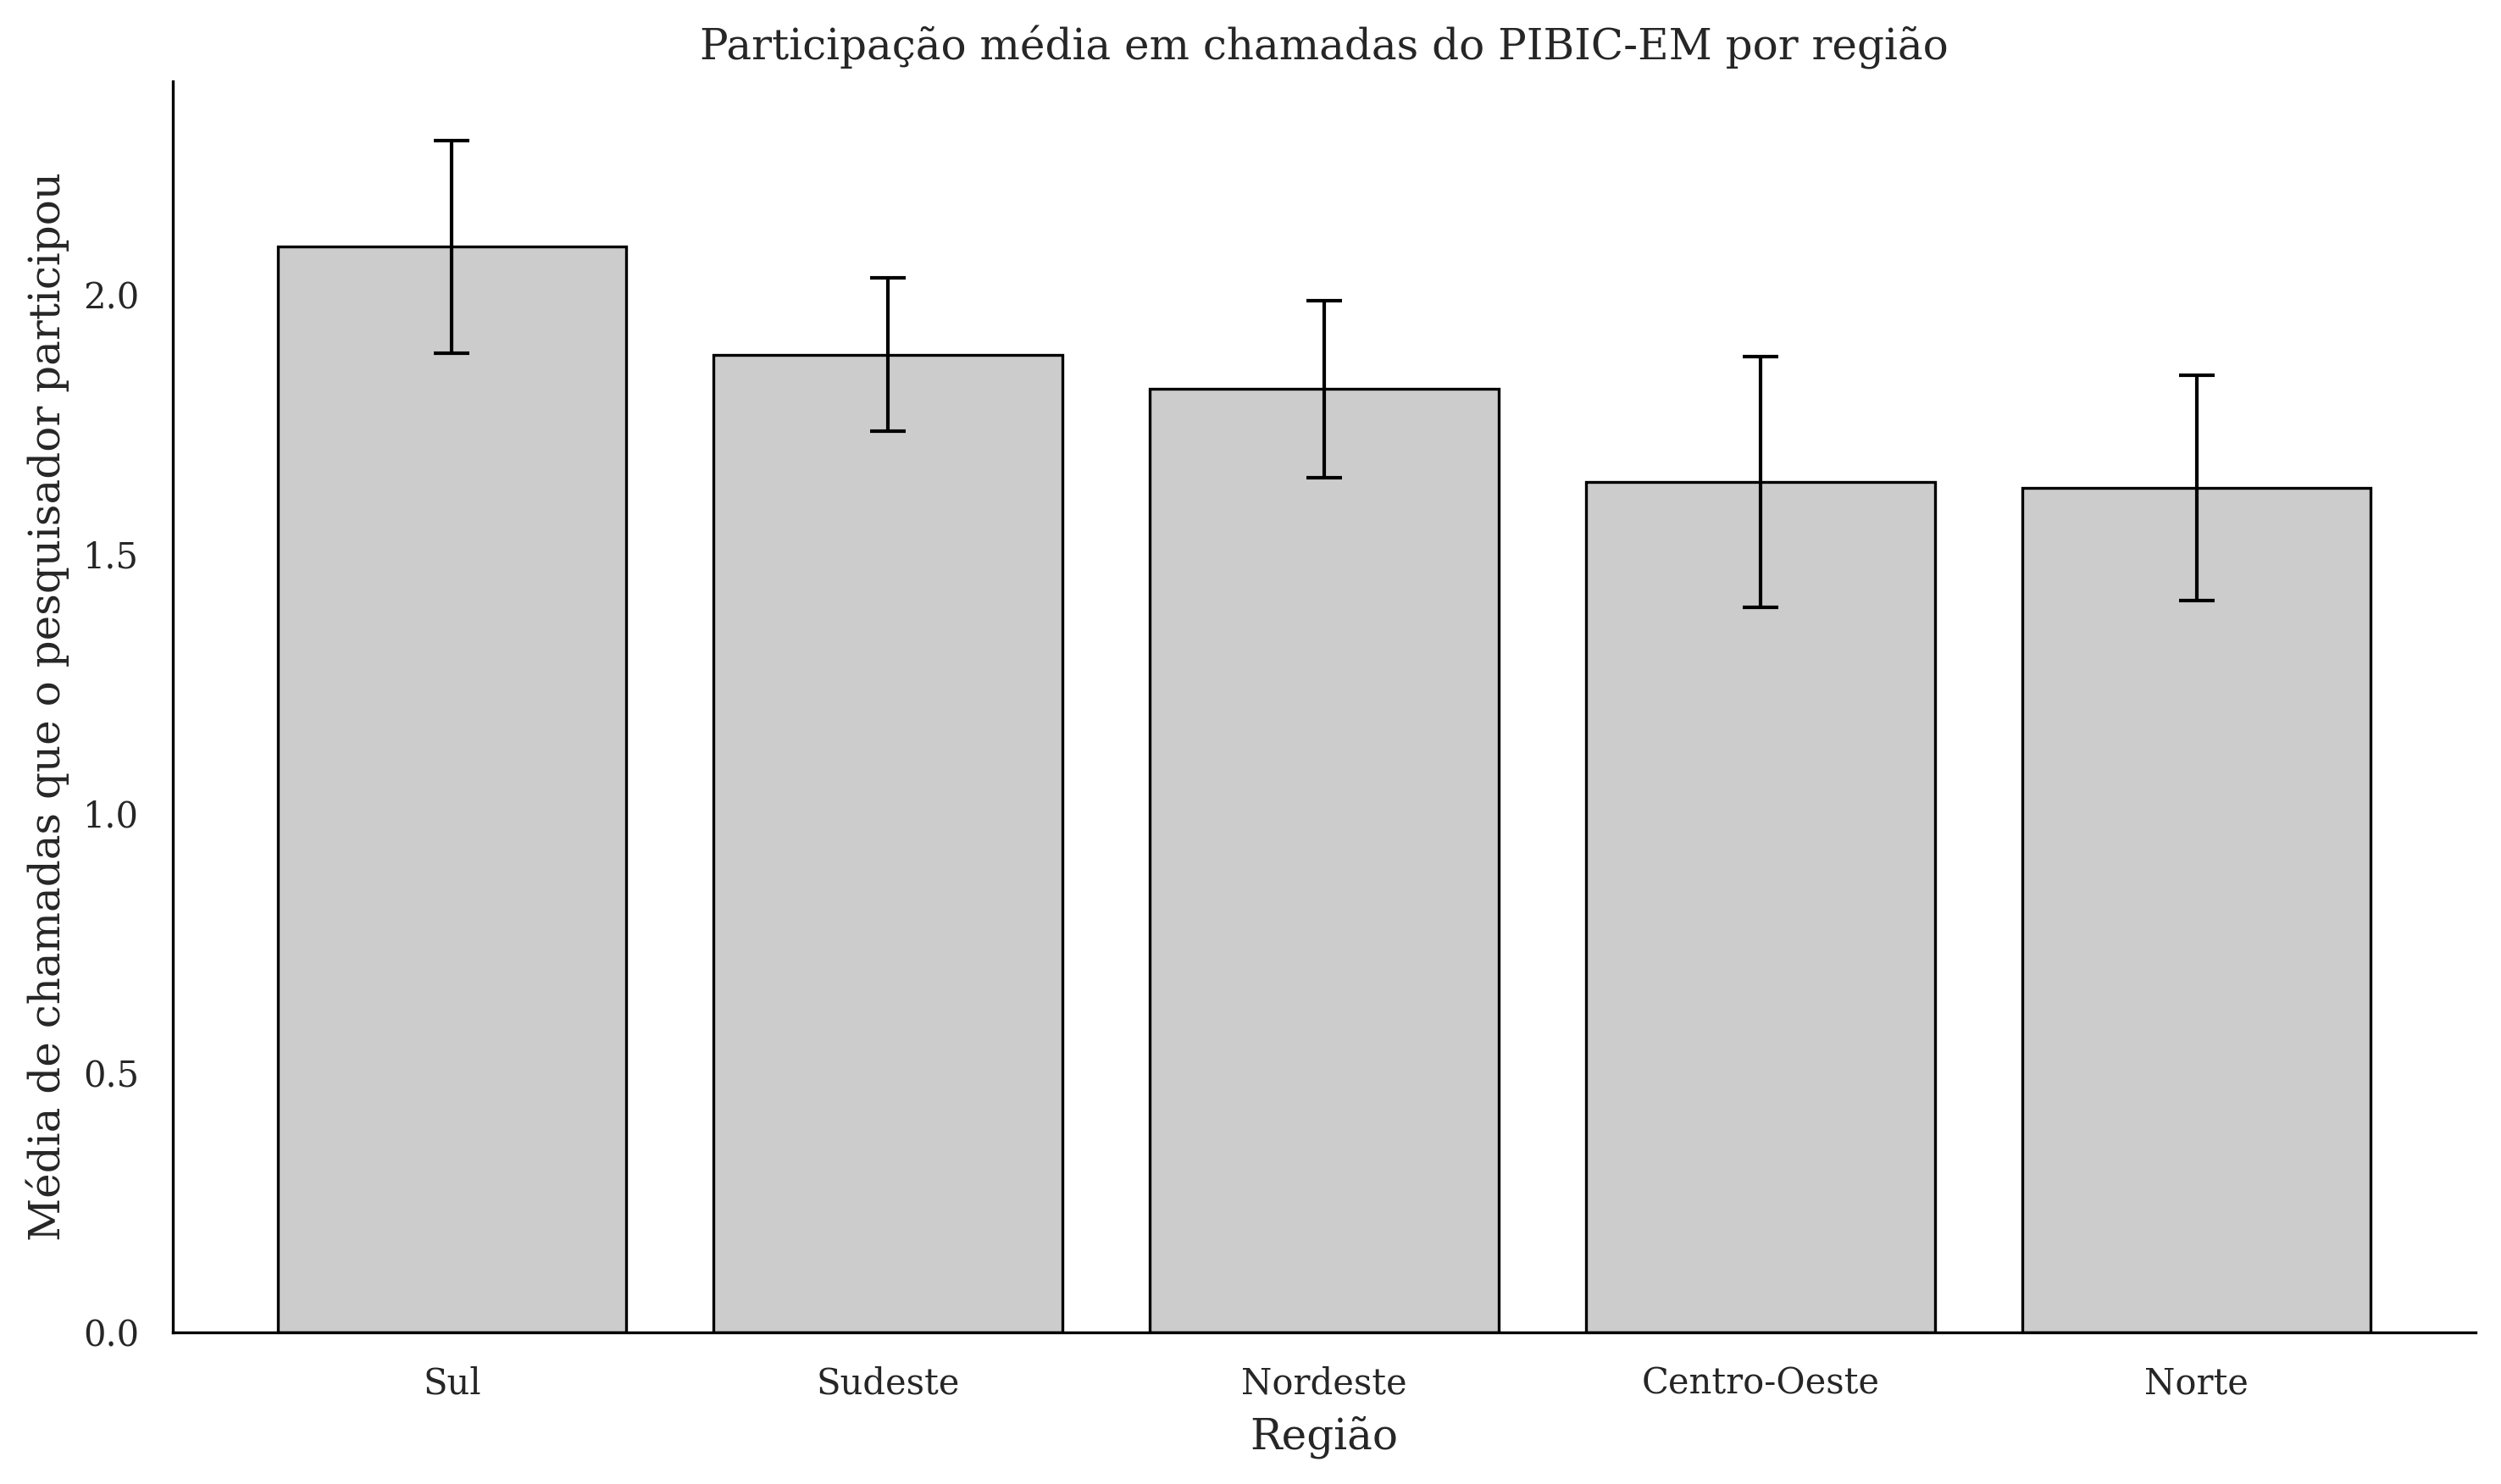

 -> fig_regioes_bar_PT_color.png


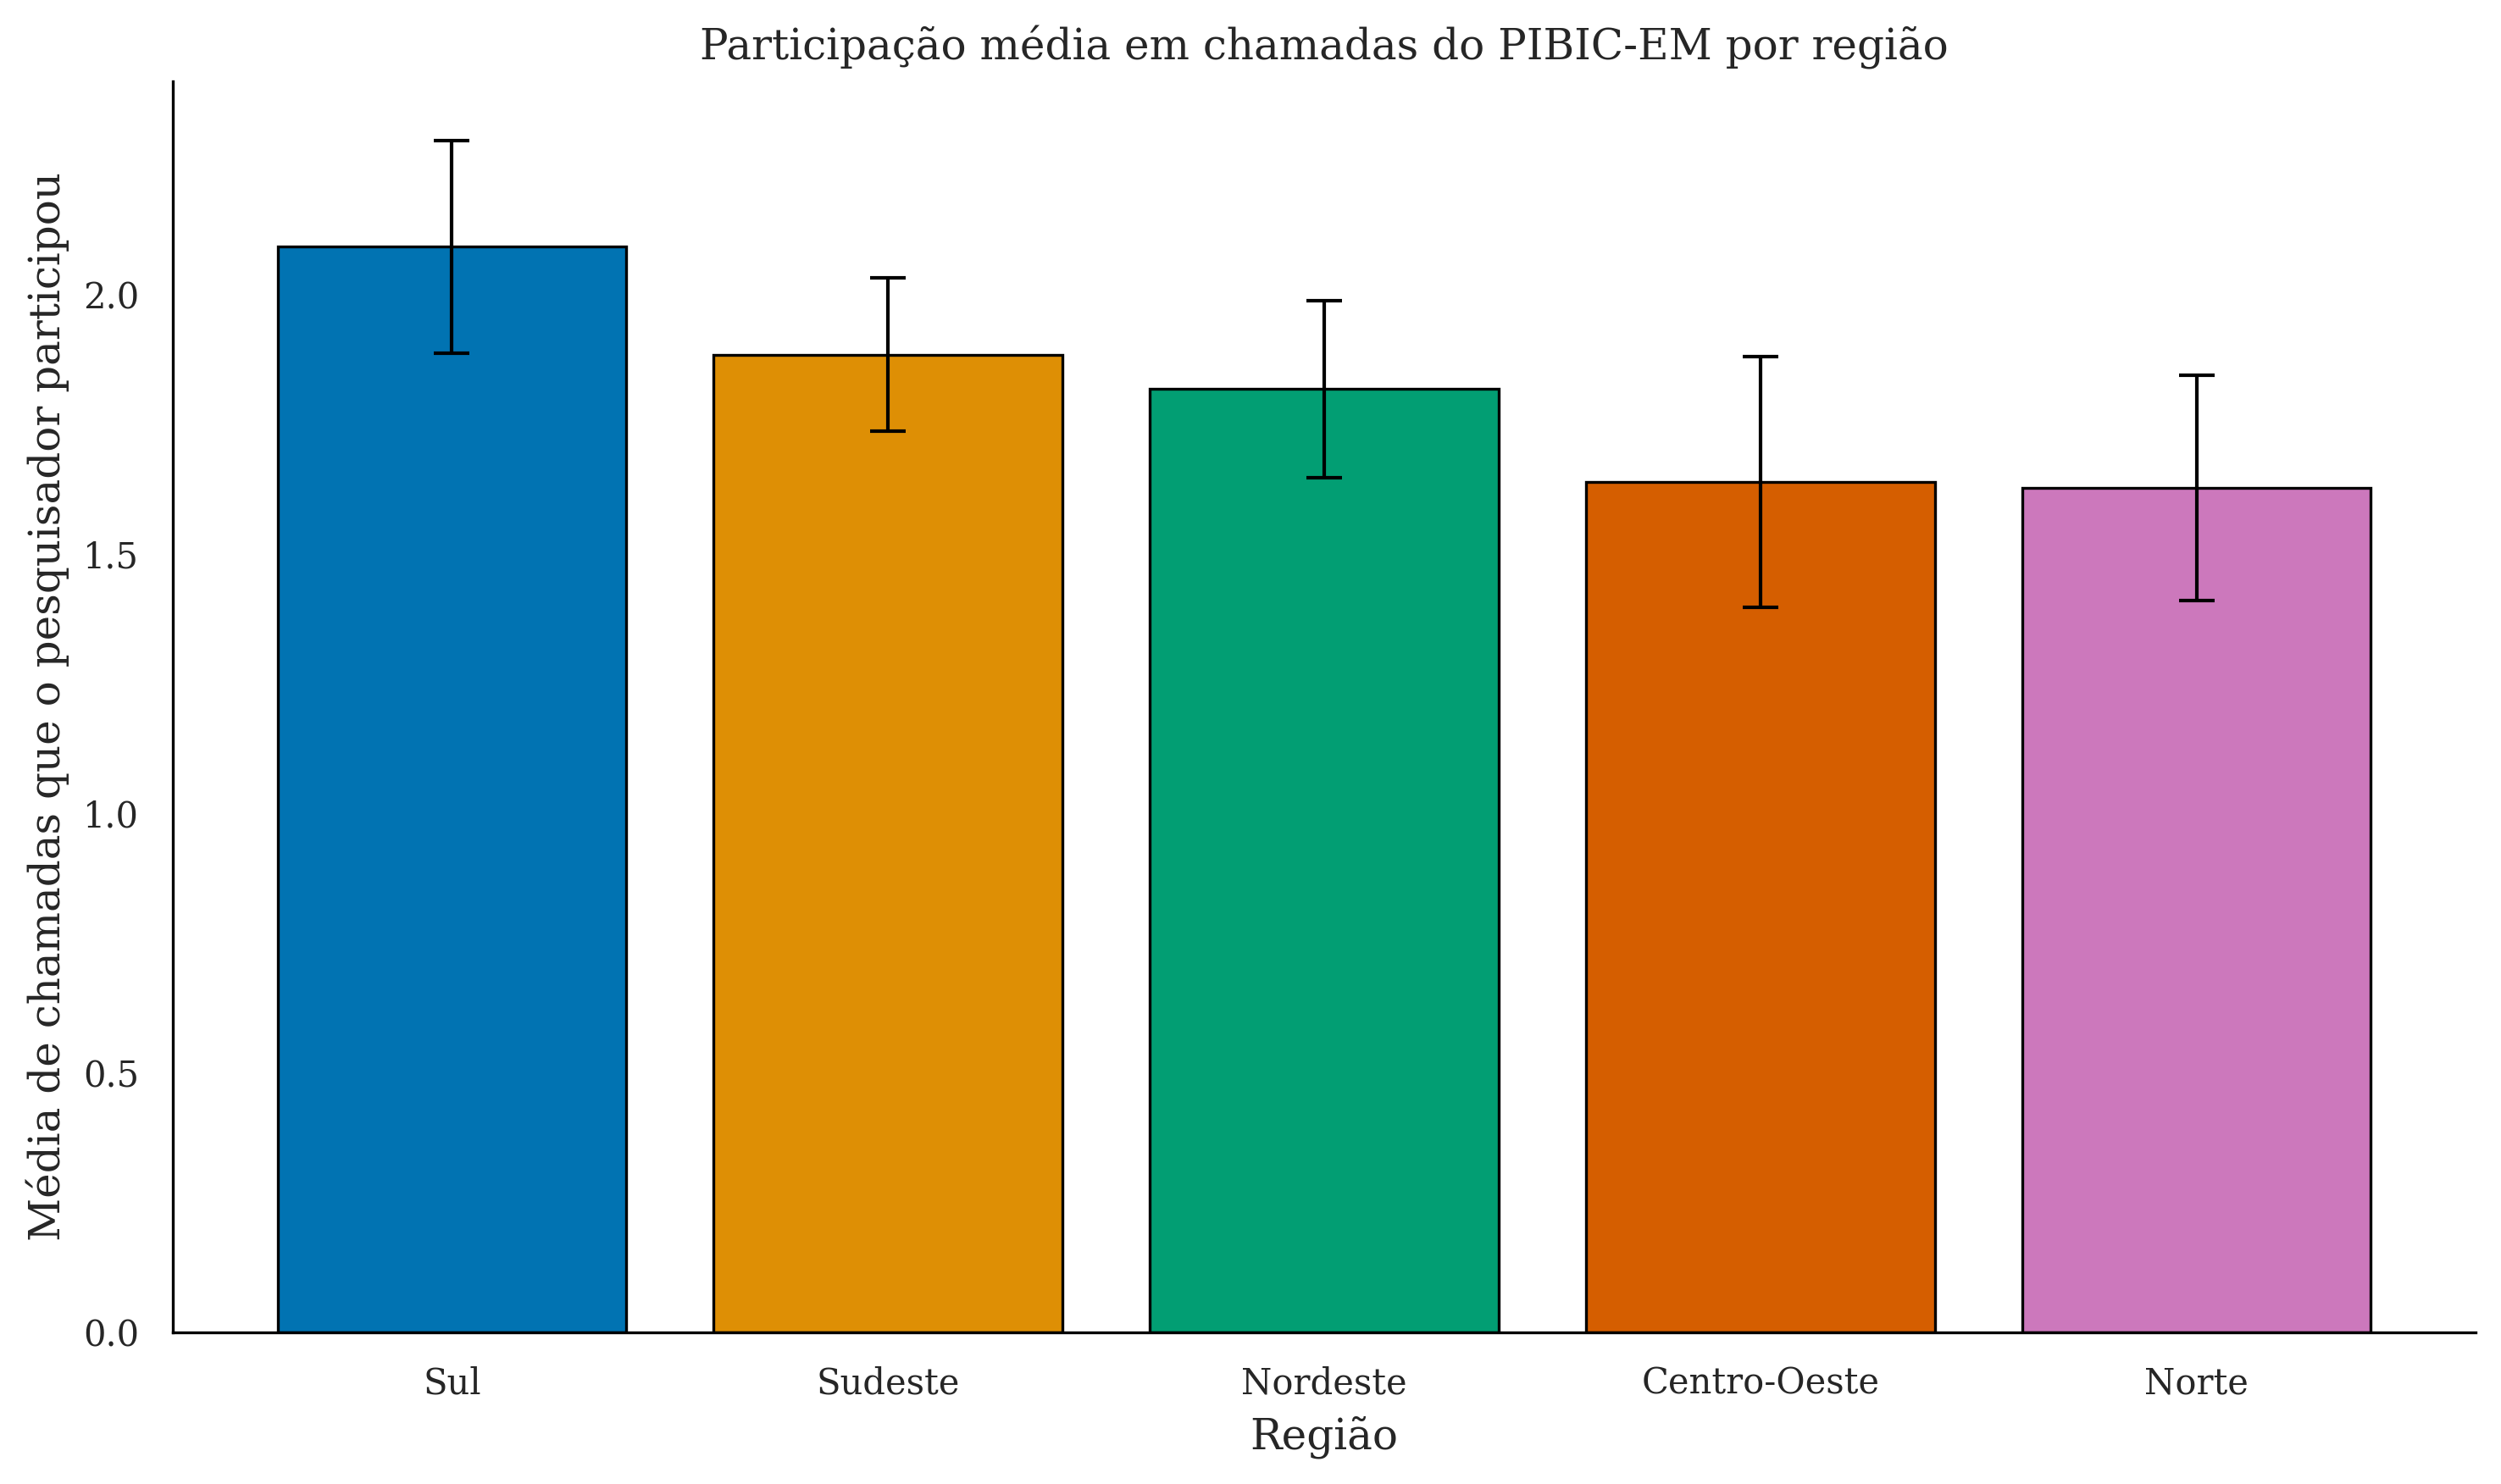

 -> fig_regioes_bar_EN_gray.png


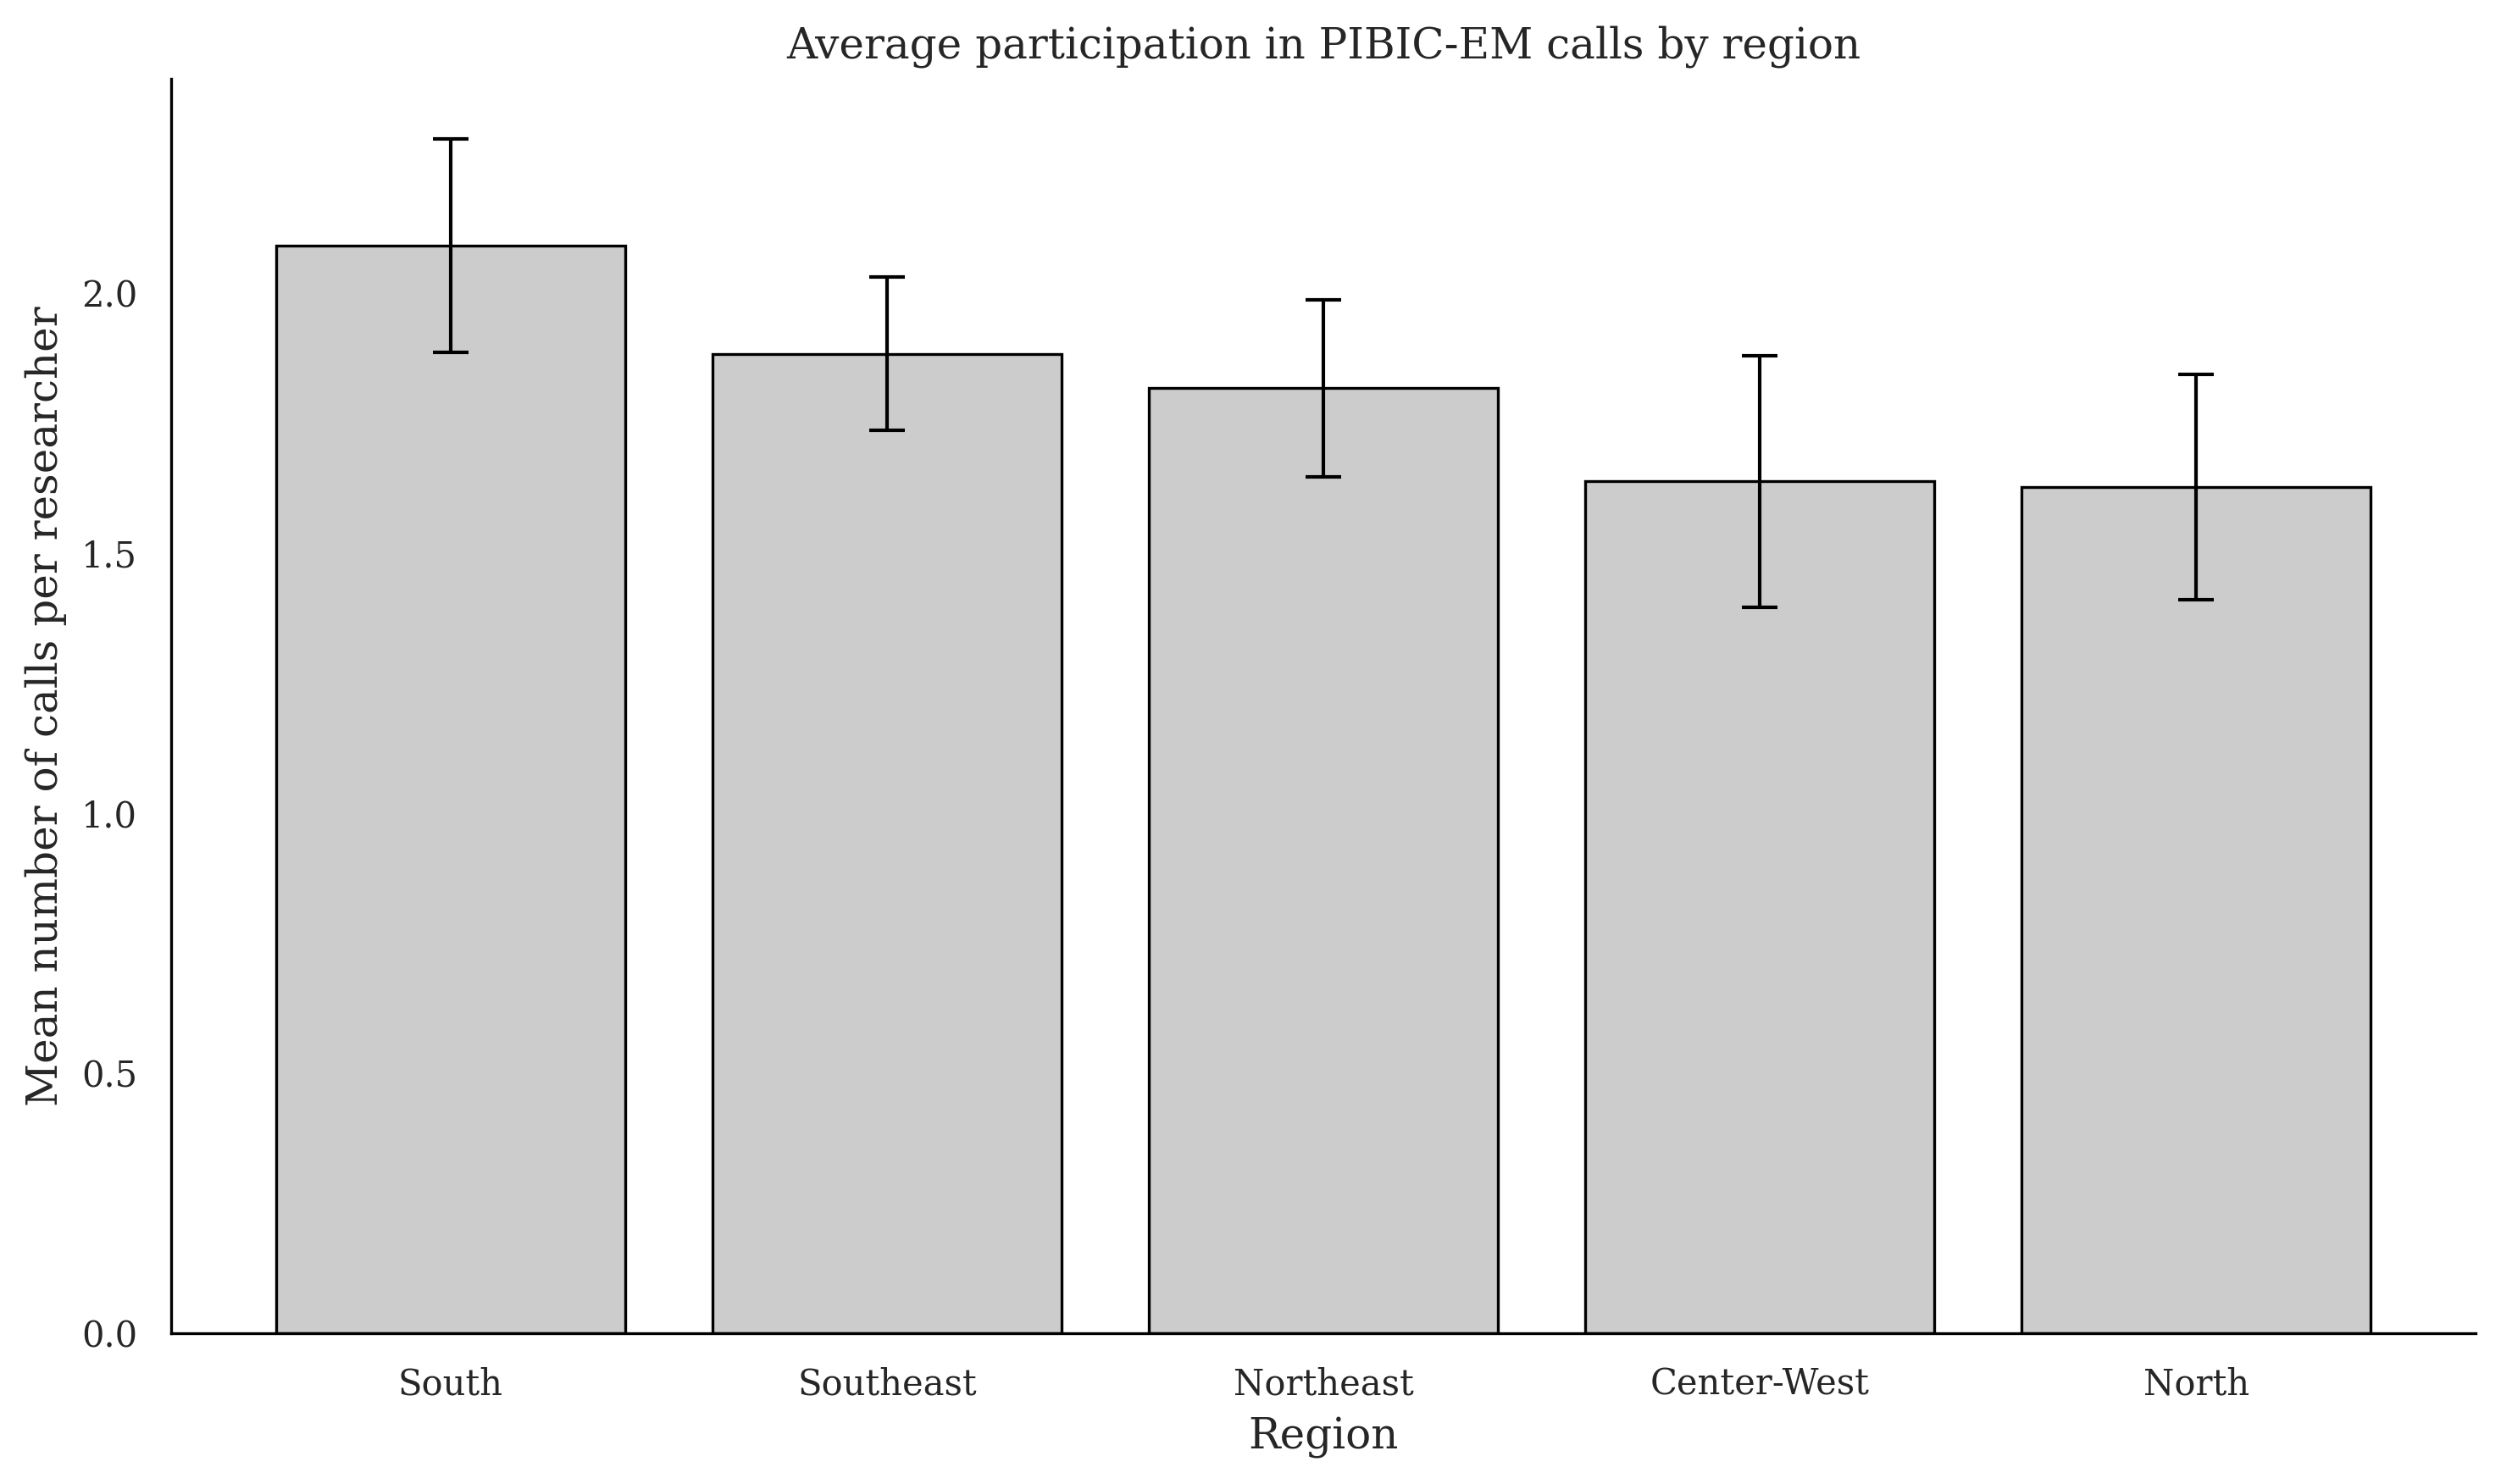

 -> fig_regioes_bar_EN_color.png


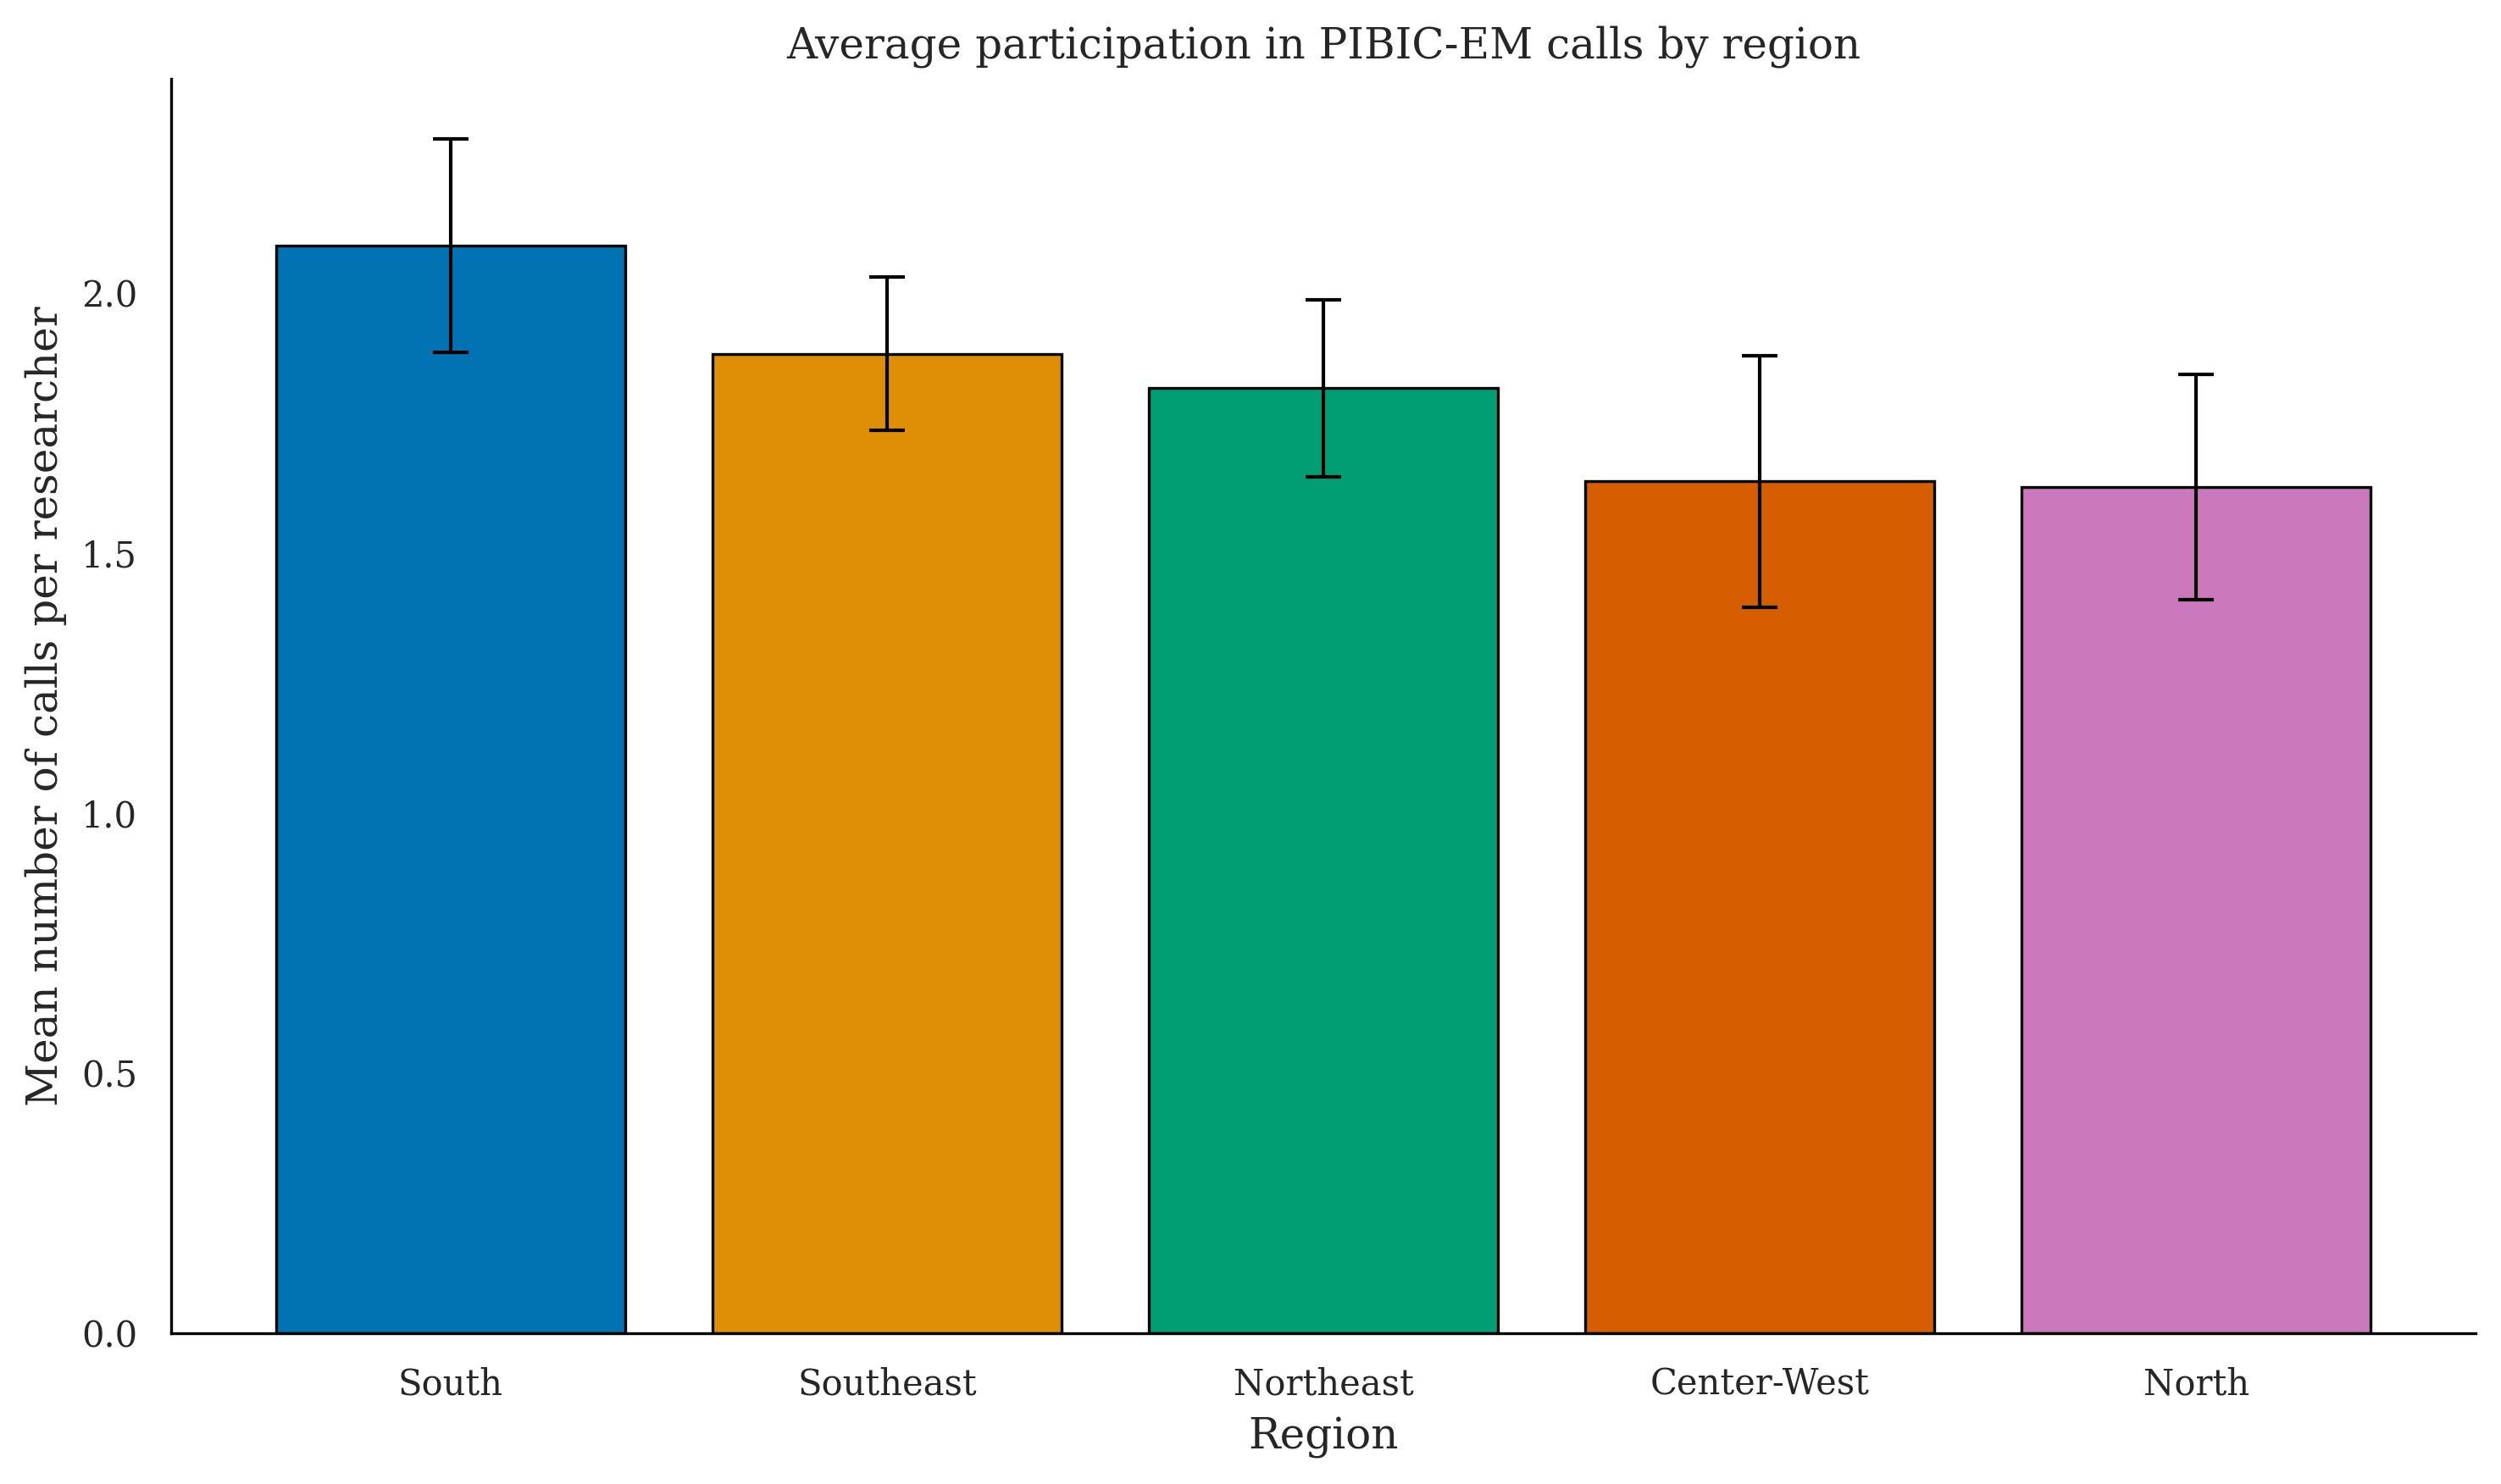


Gerando Gráfico 2 (boxplots por região)...
 -> fig_regioes_box_PT_cinza.png


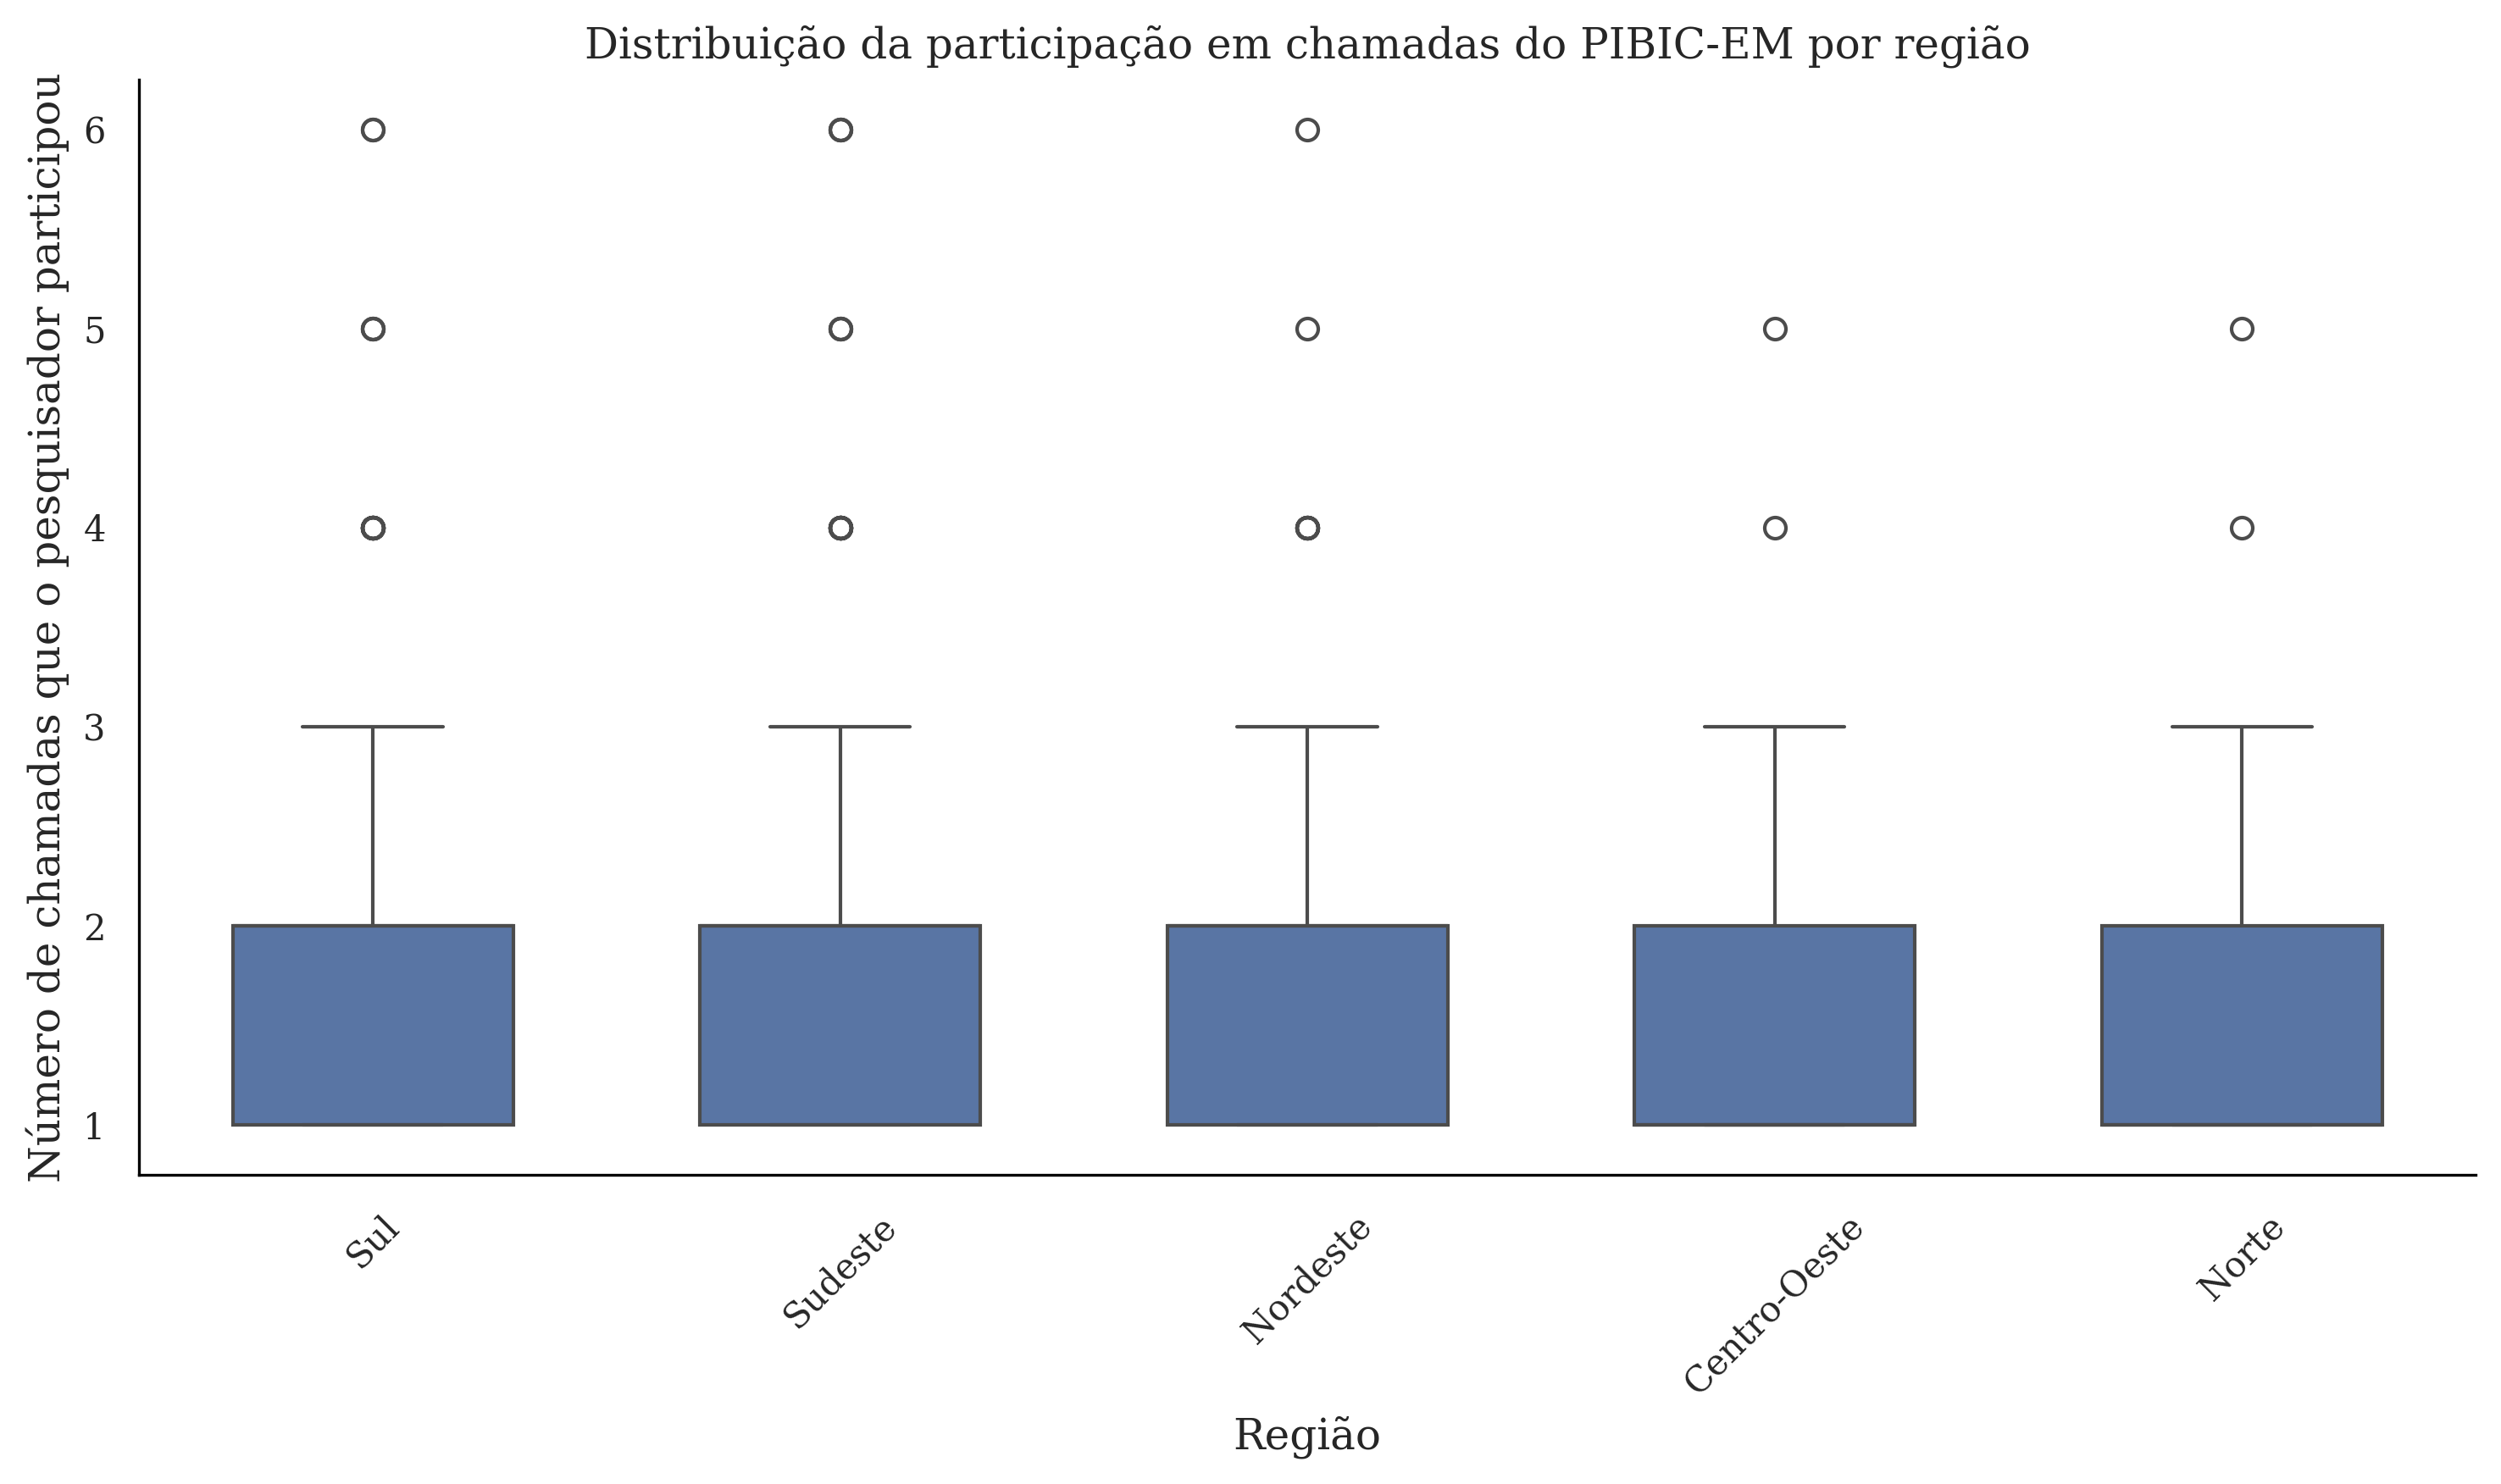

 -> fig_regioes_box_PT_color.png


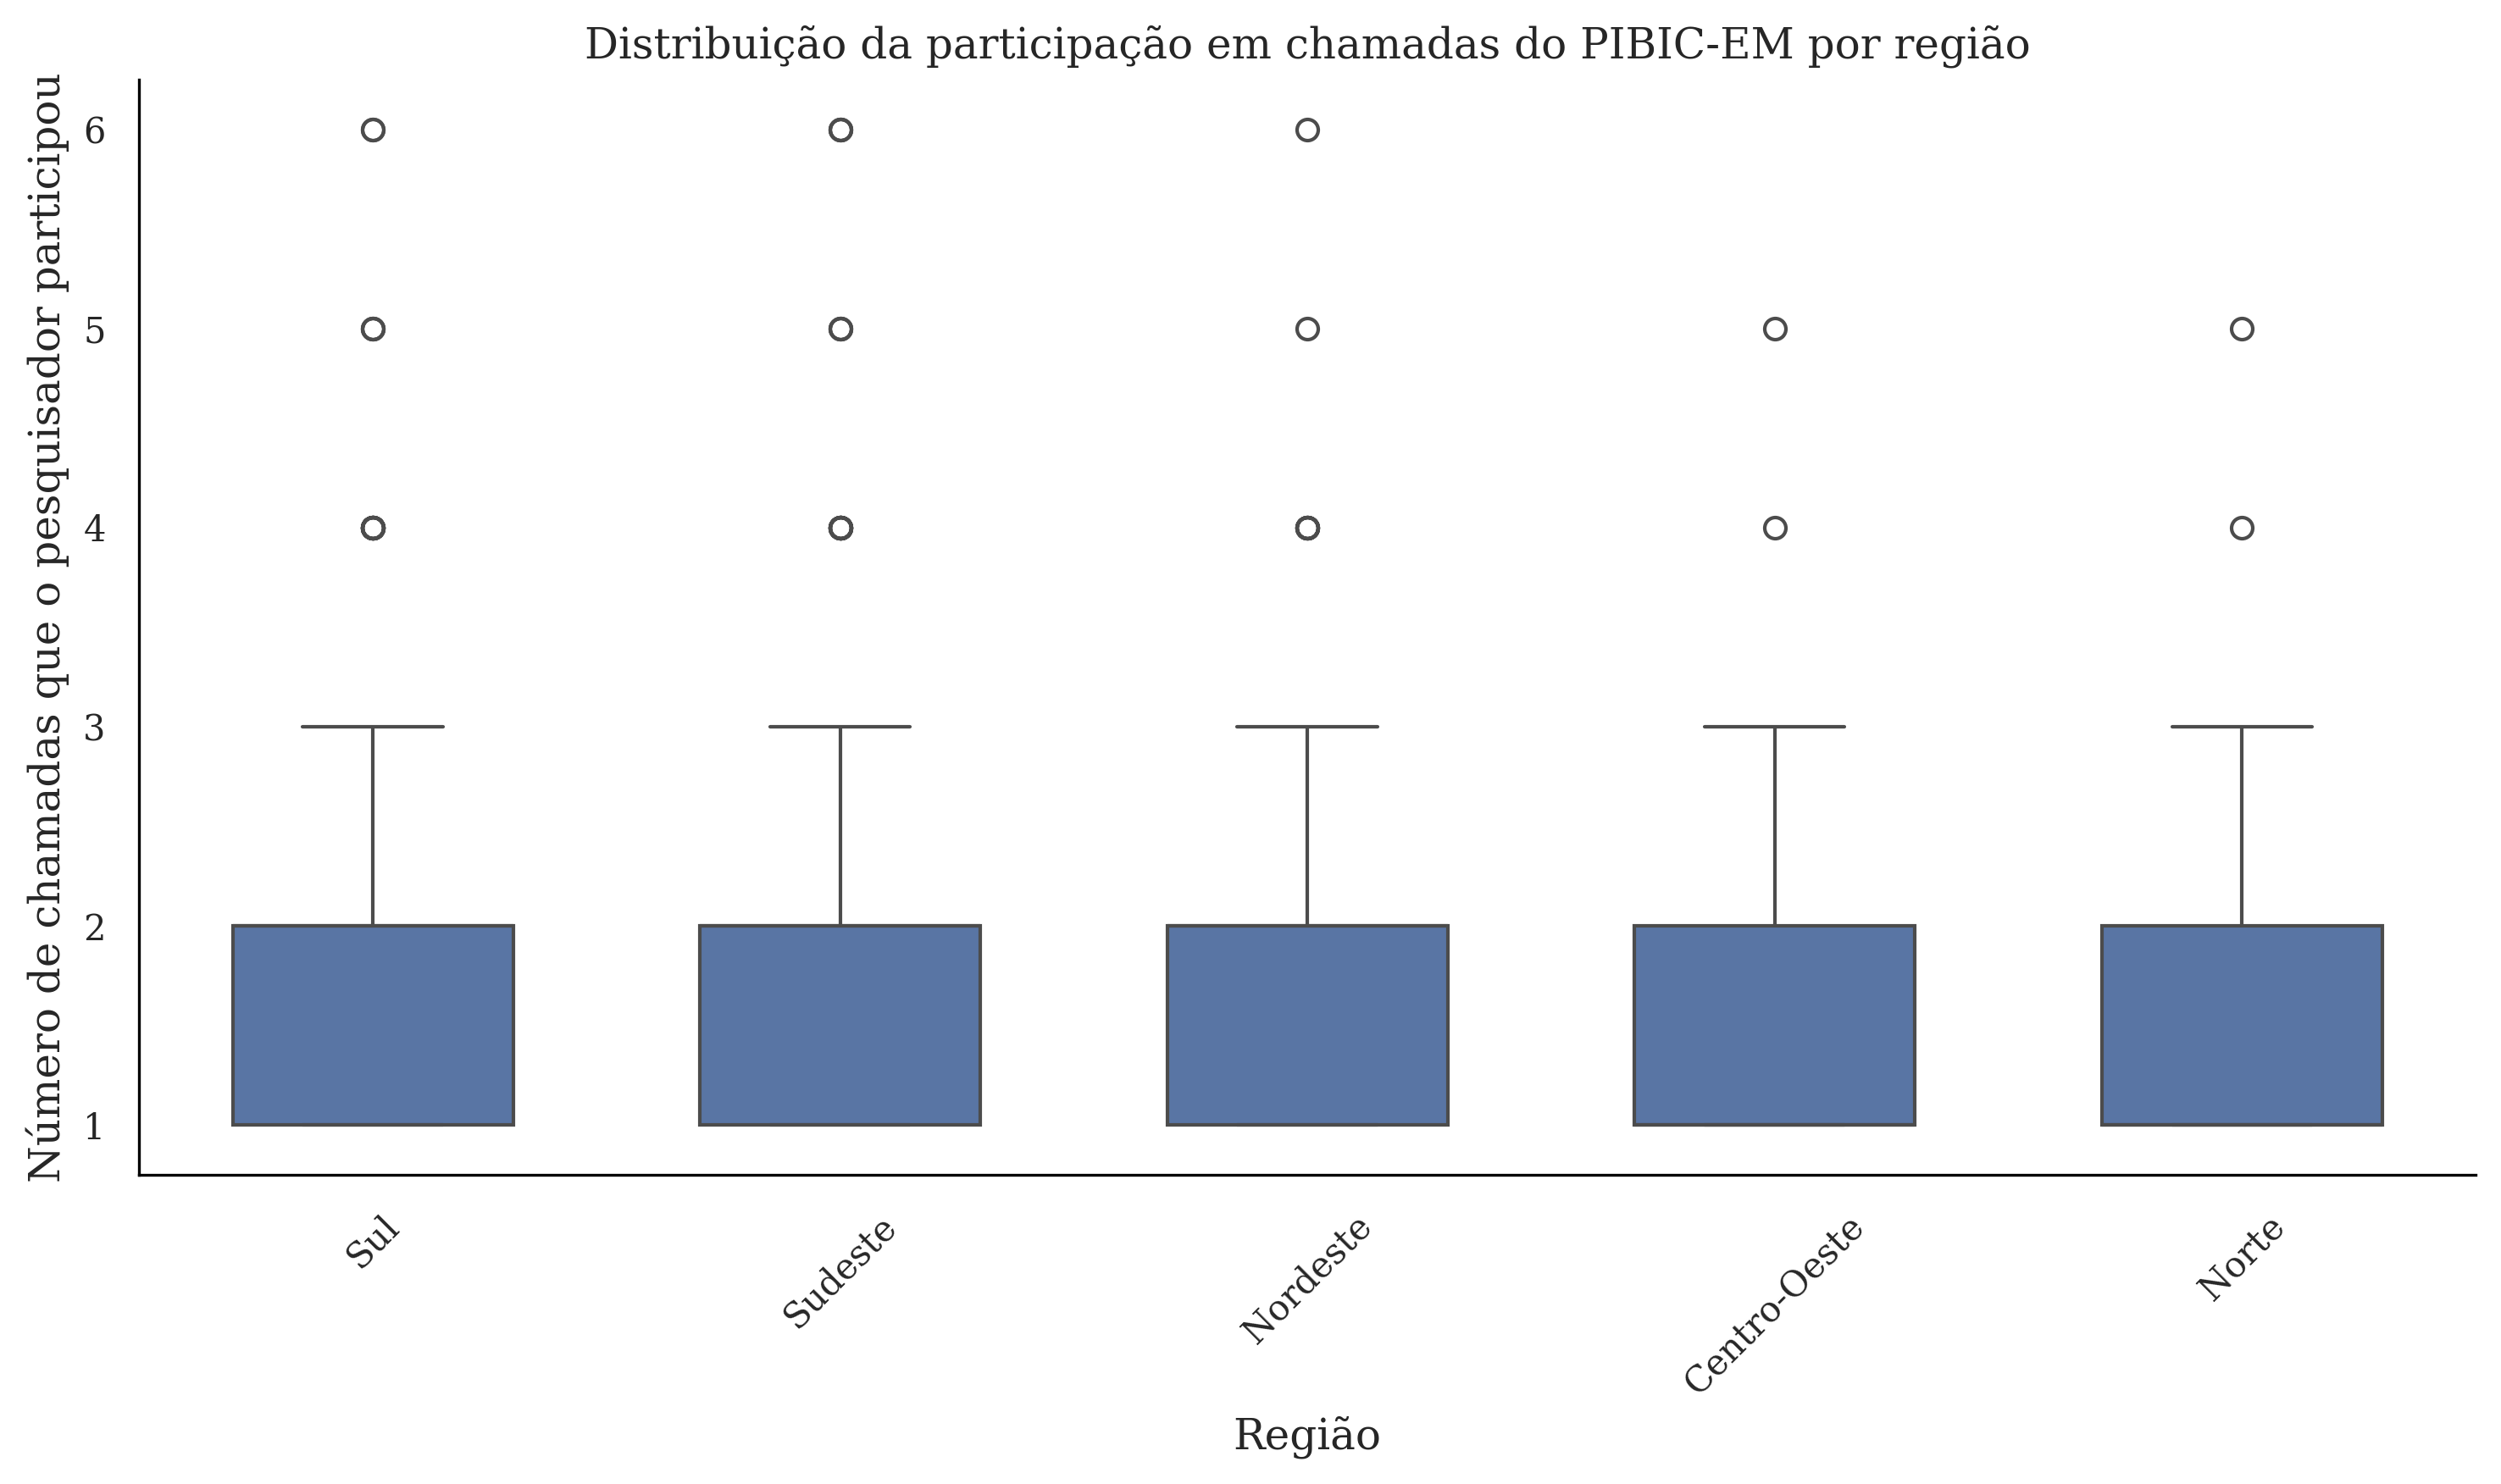

 -> fig_regioes_box_EN_gray.png


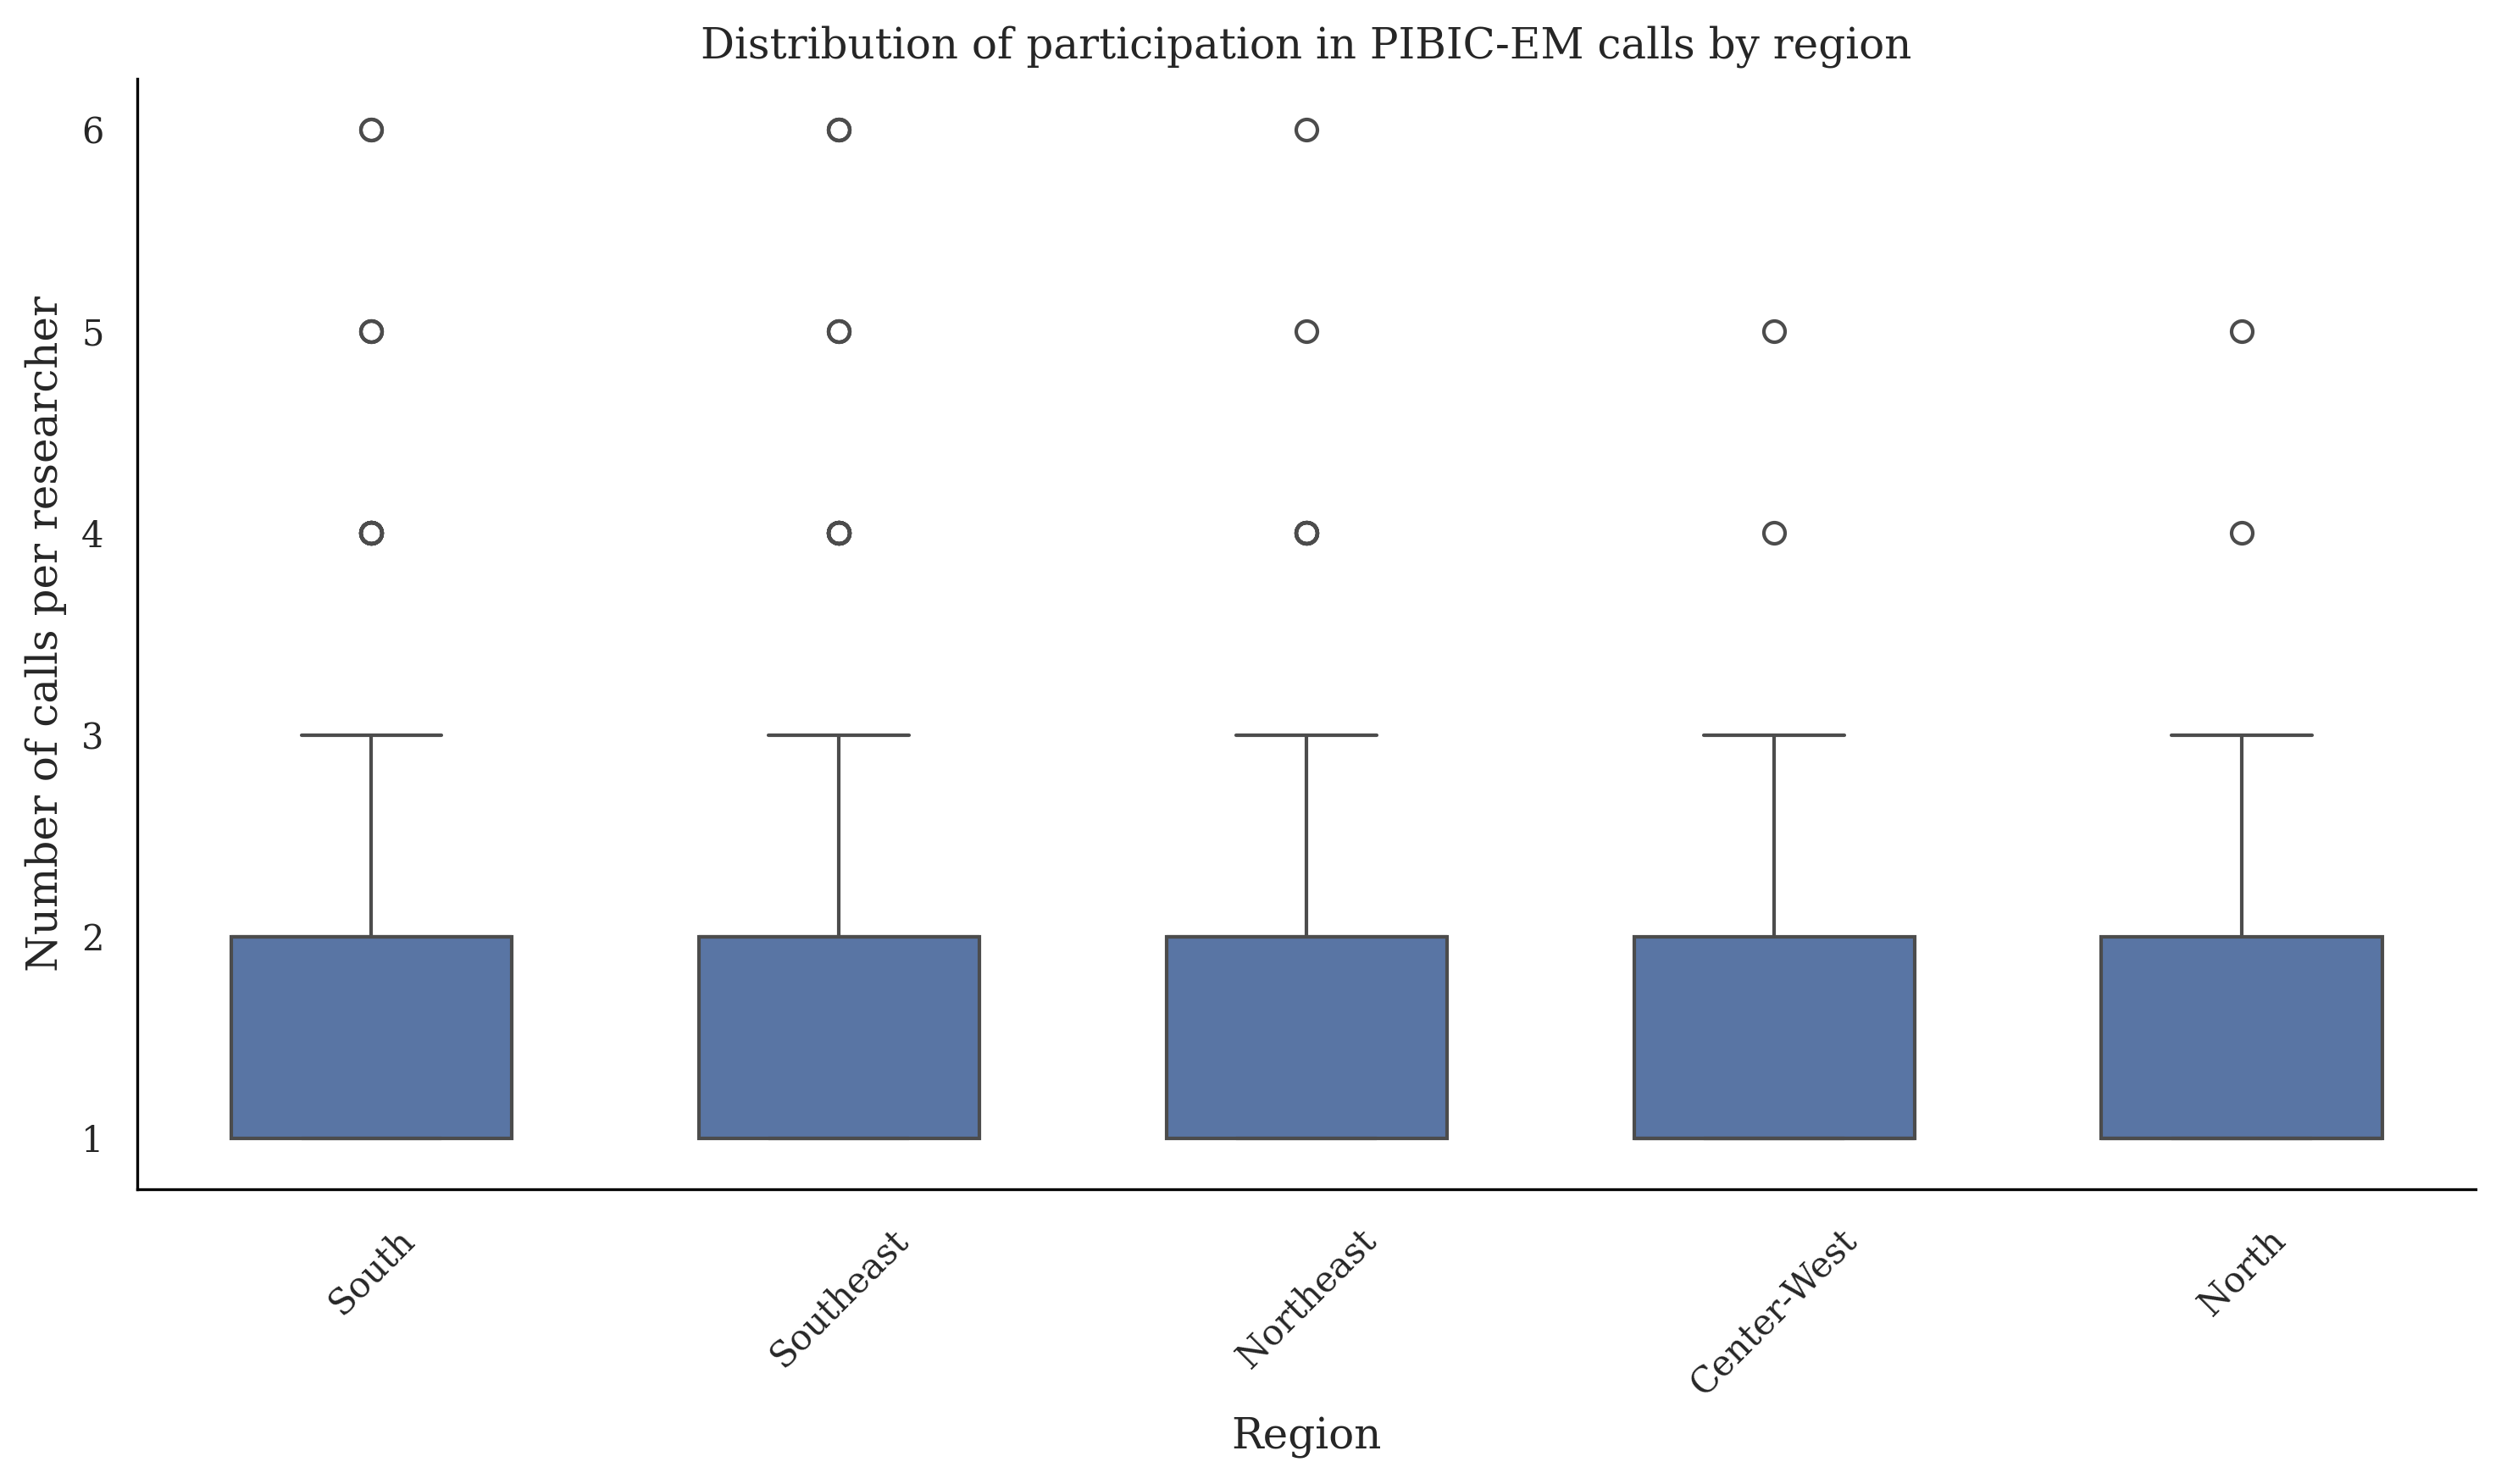

 -> fig_regioes_box_EN_color.png


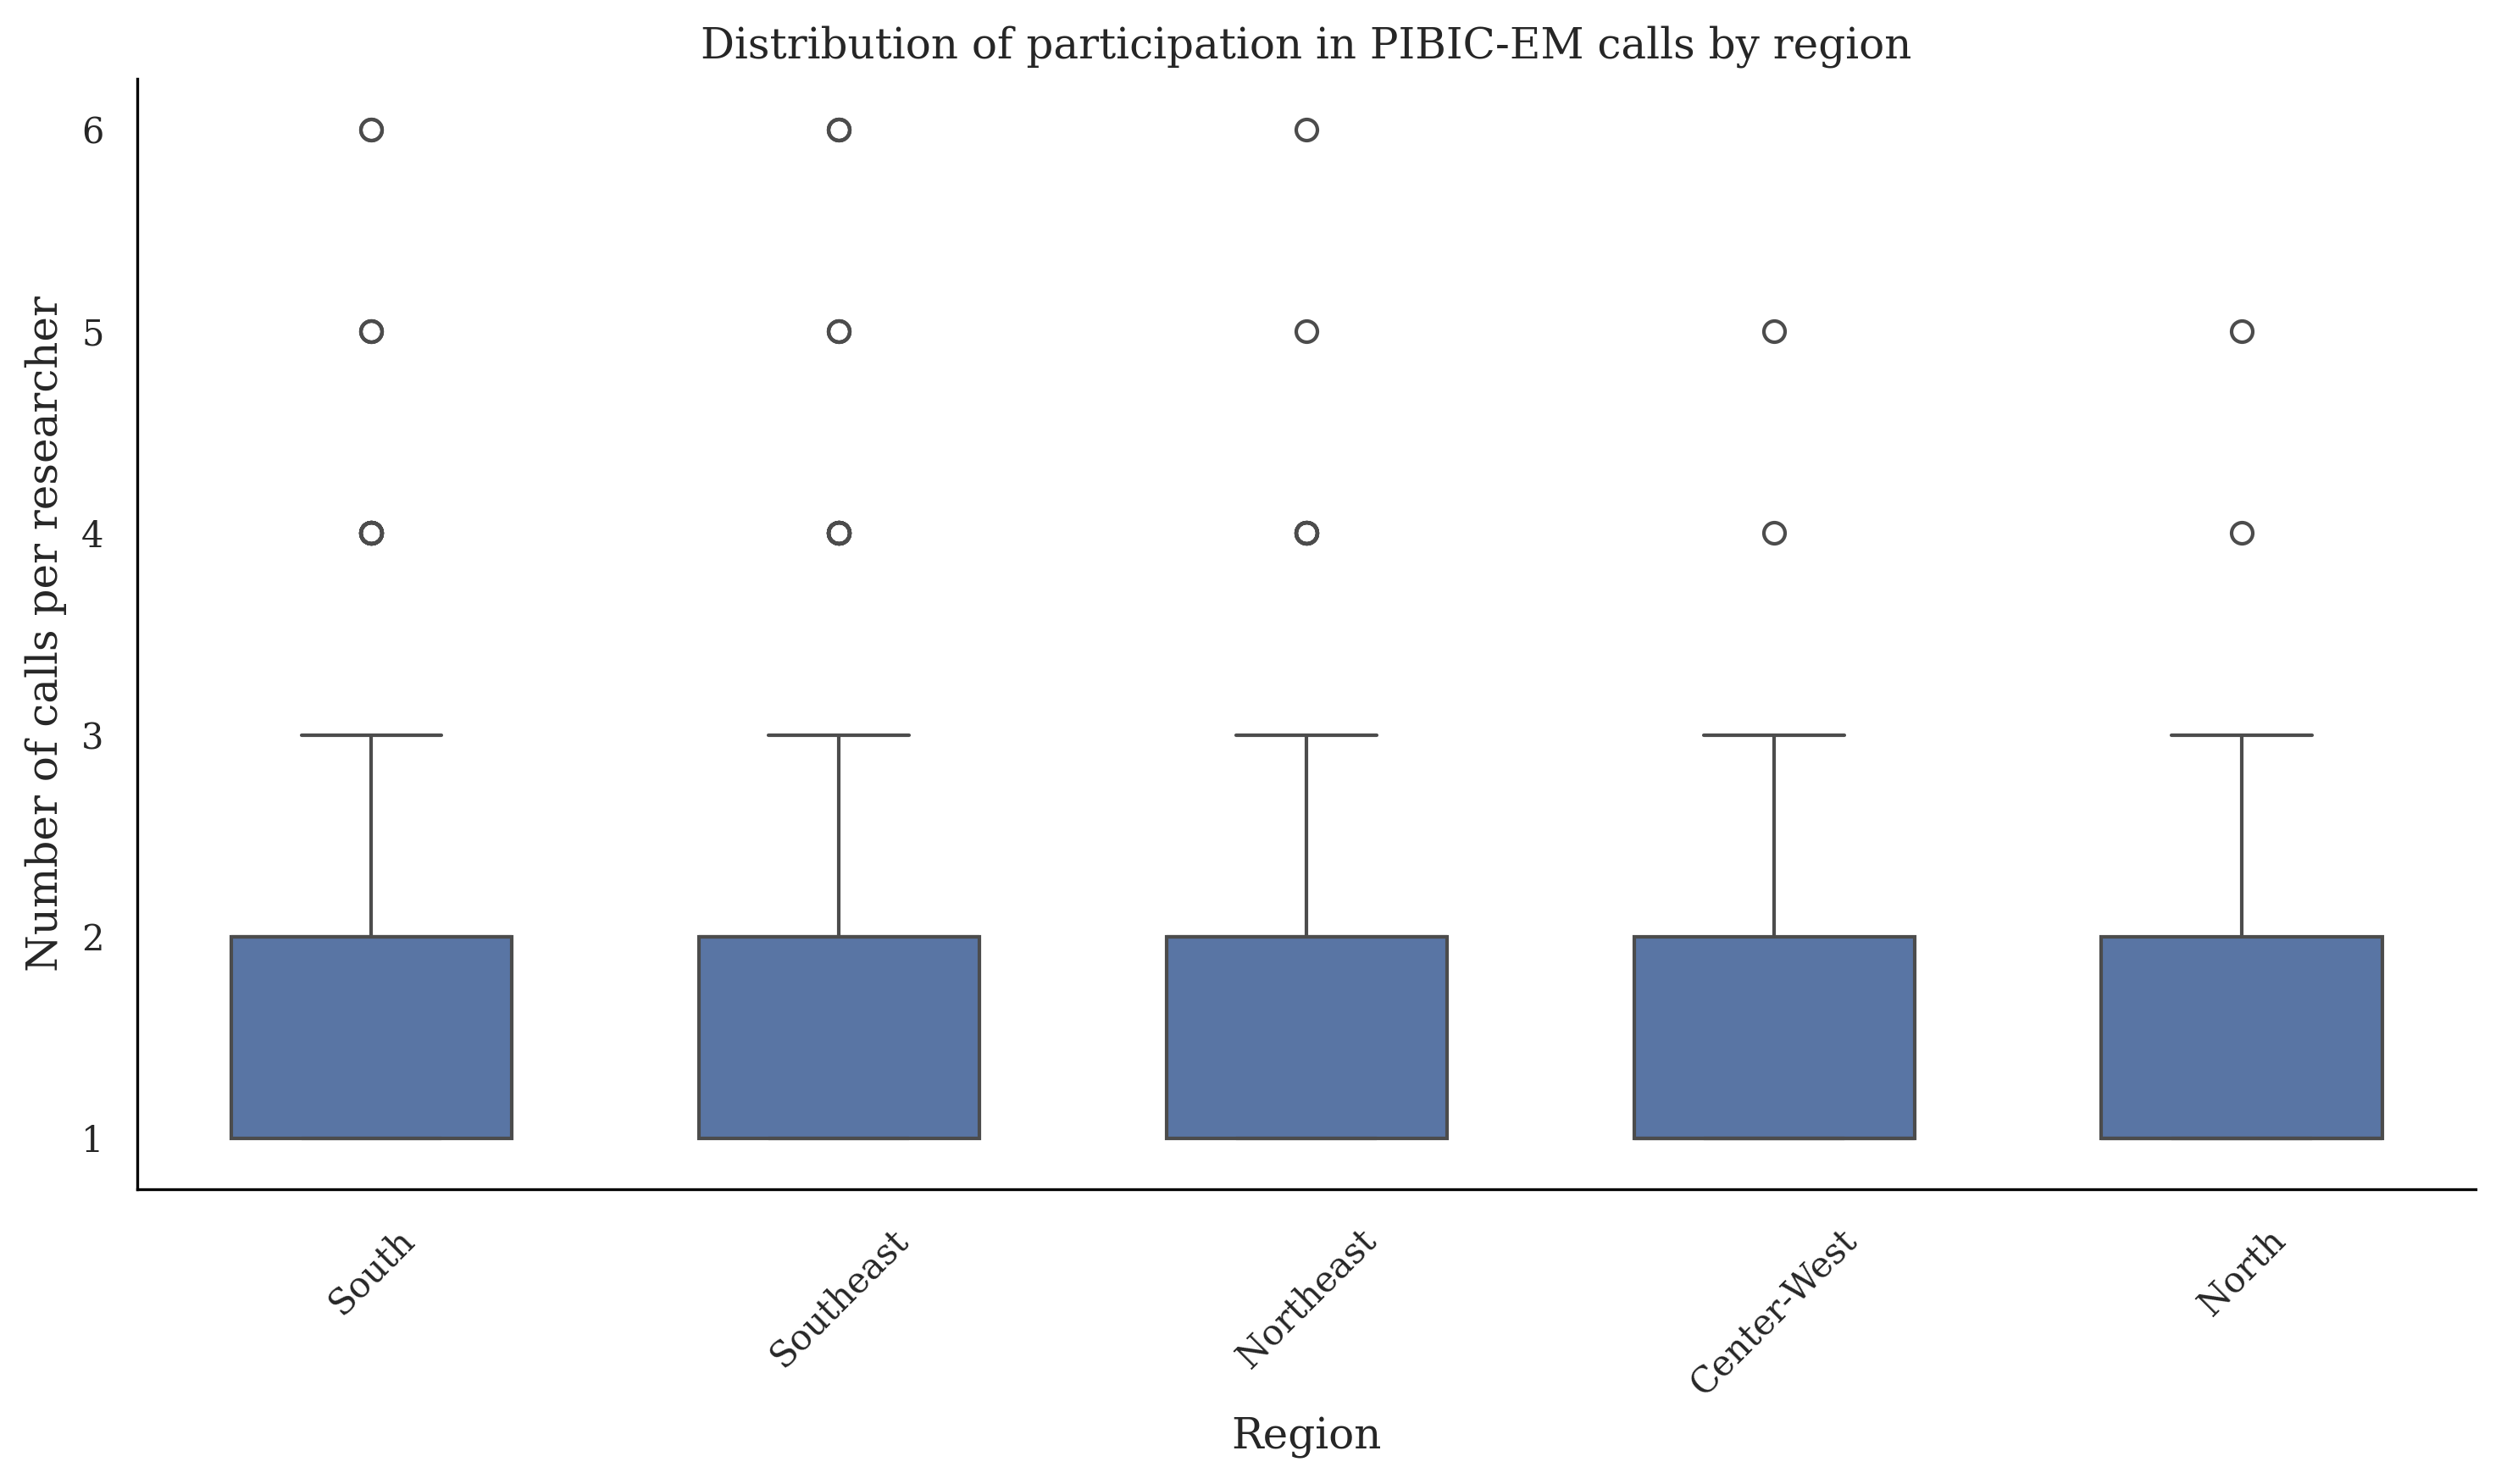


Gerando Gráfico 3 (forest plots)...
 -> fig_regioes_forest_PT_cinza.png


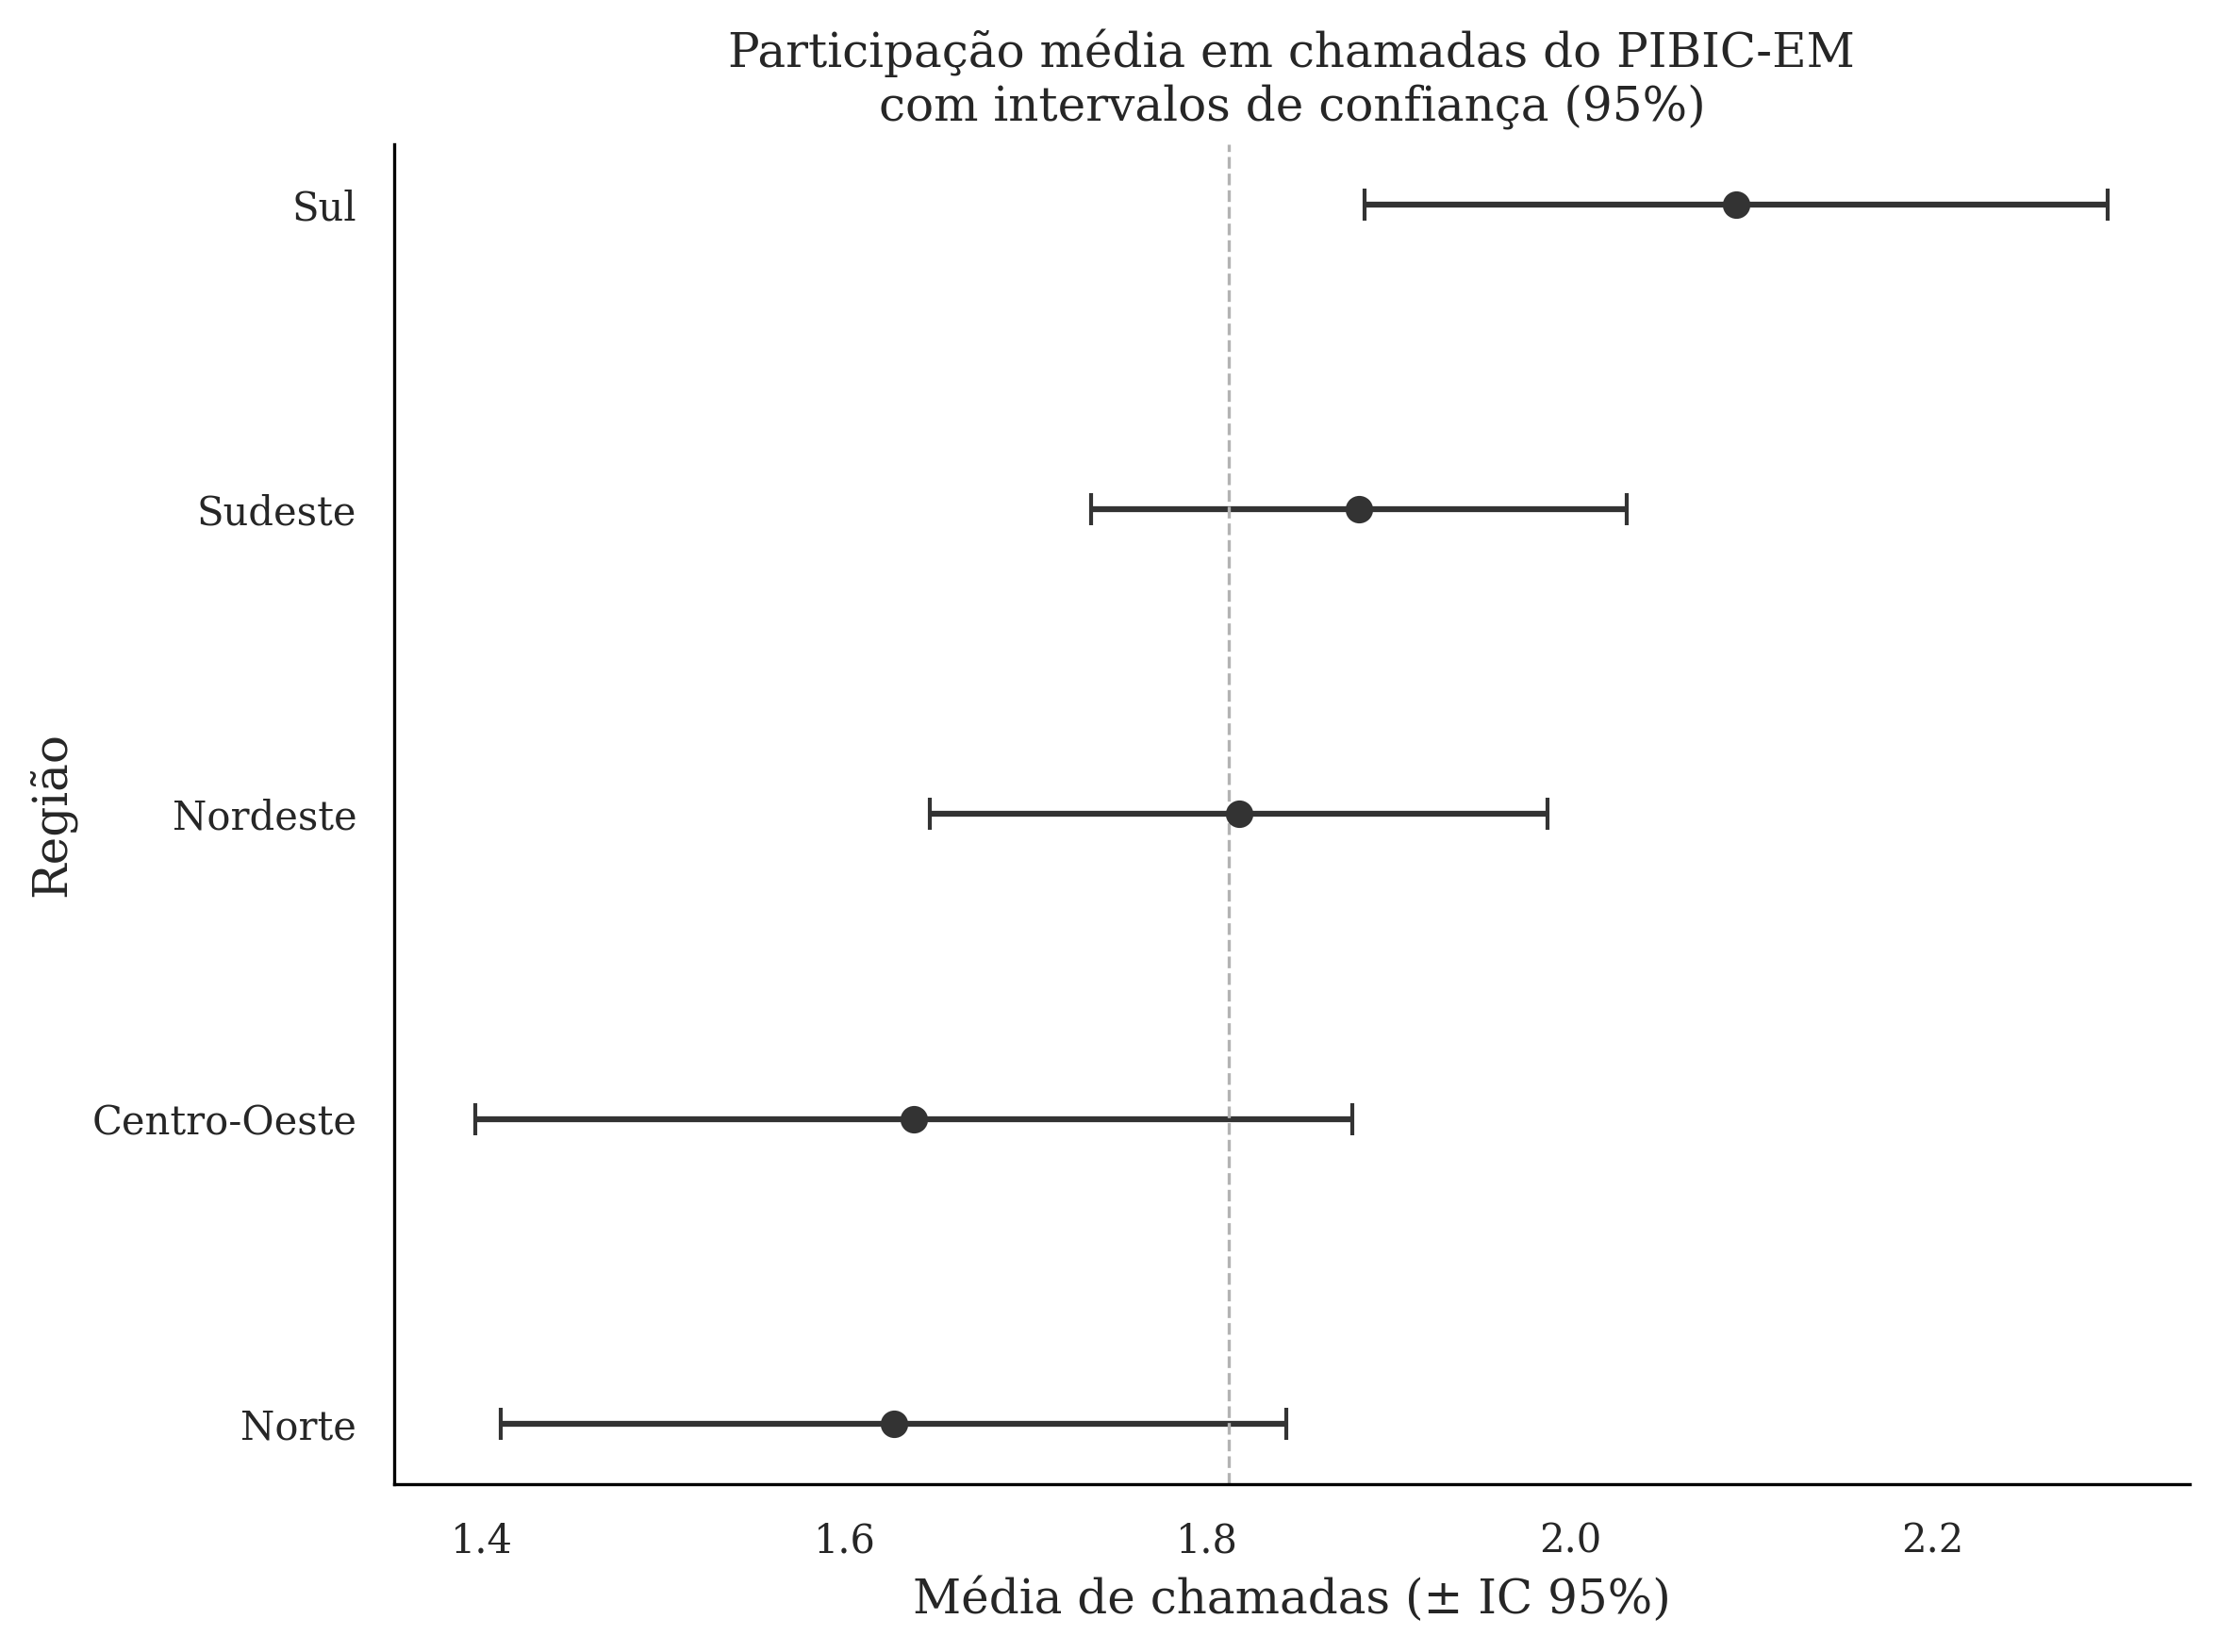

 -> fig_regioes_forest_PT_color.png


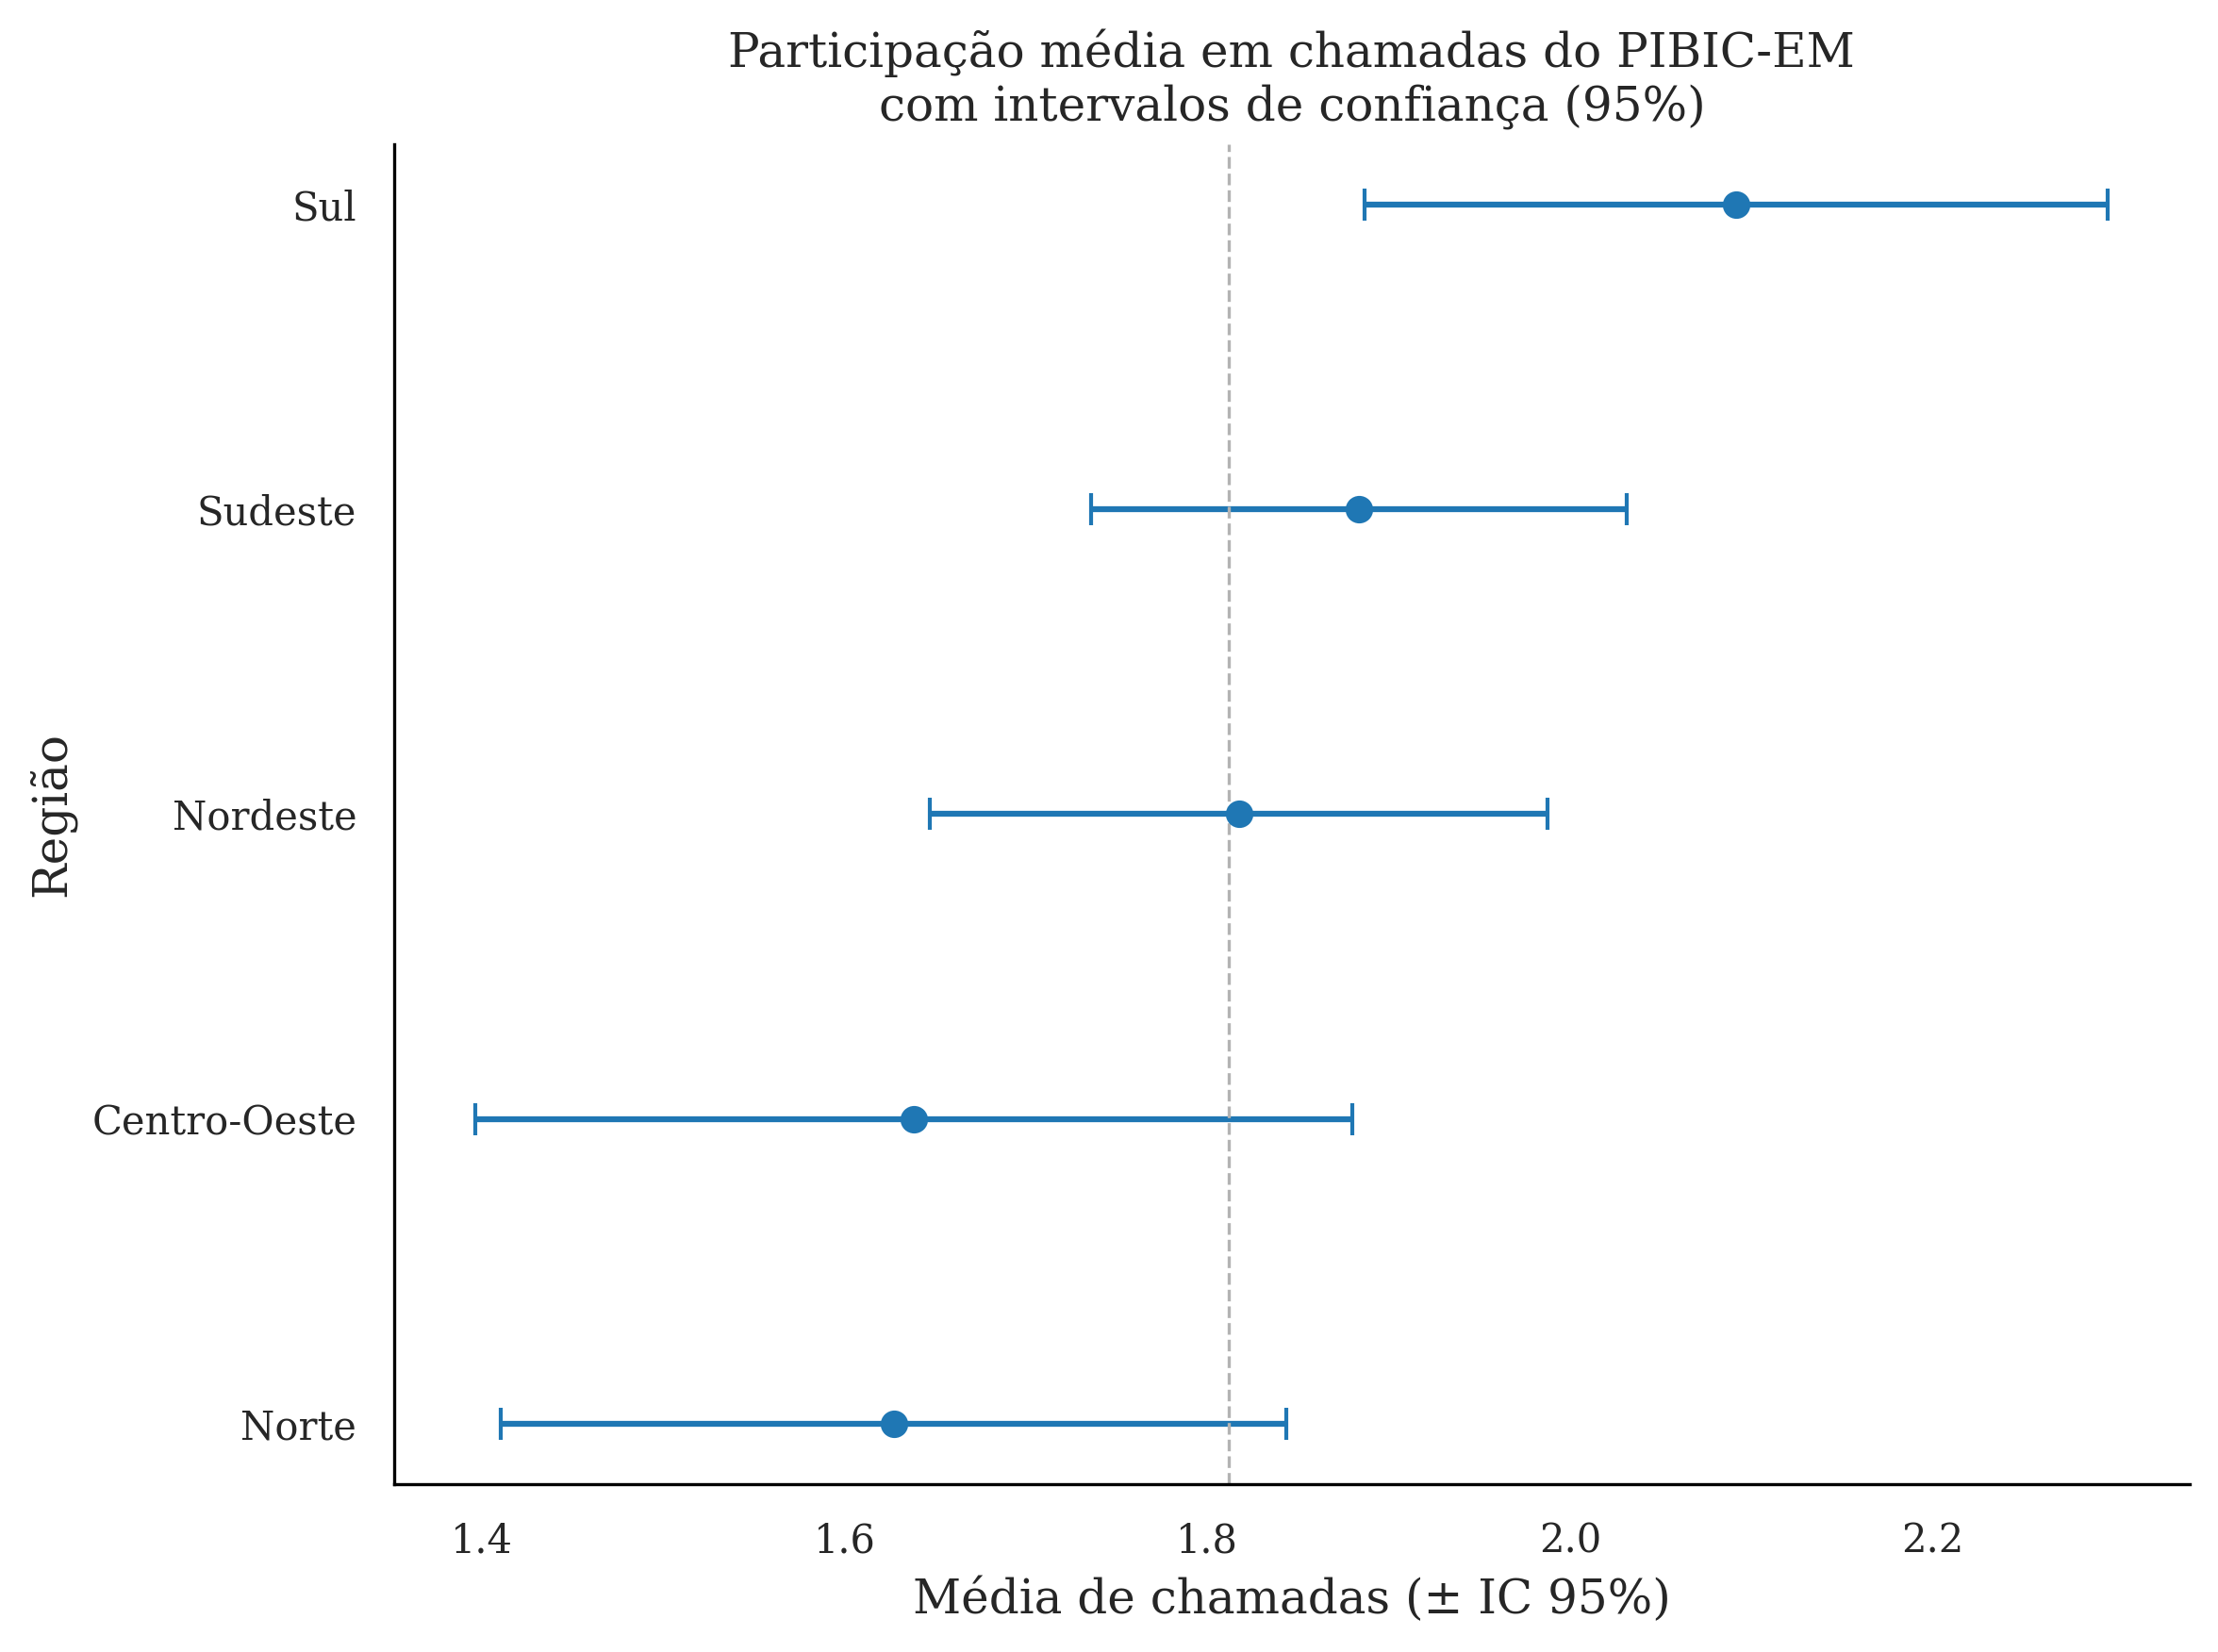

 -> fig_regioes_forest_EN_gray.png


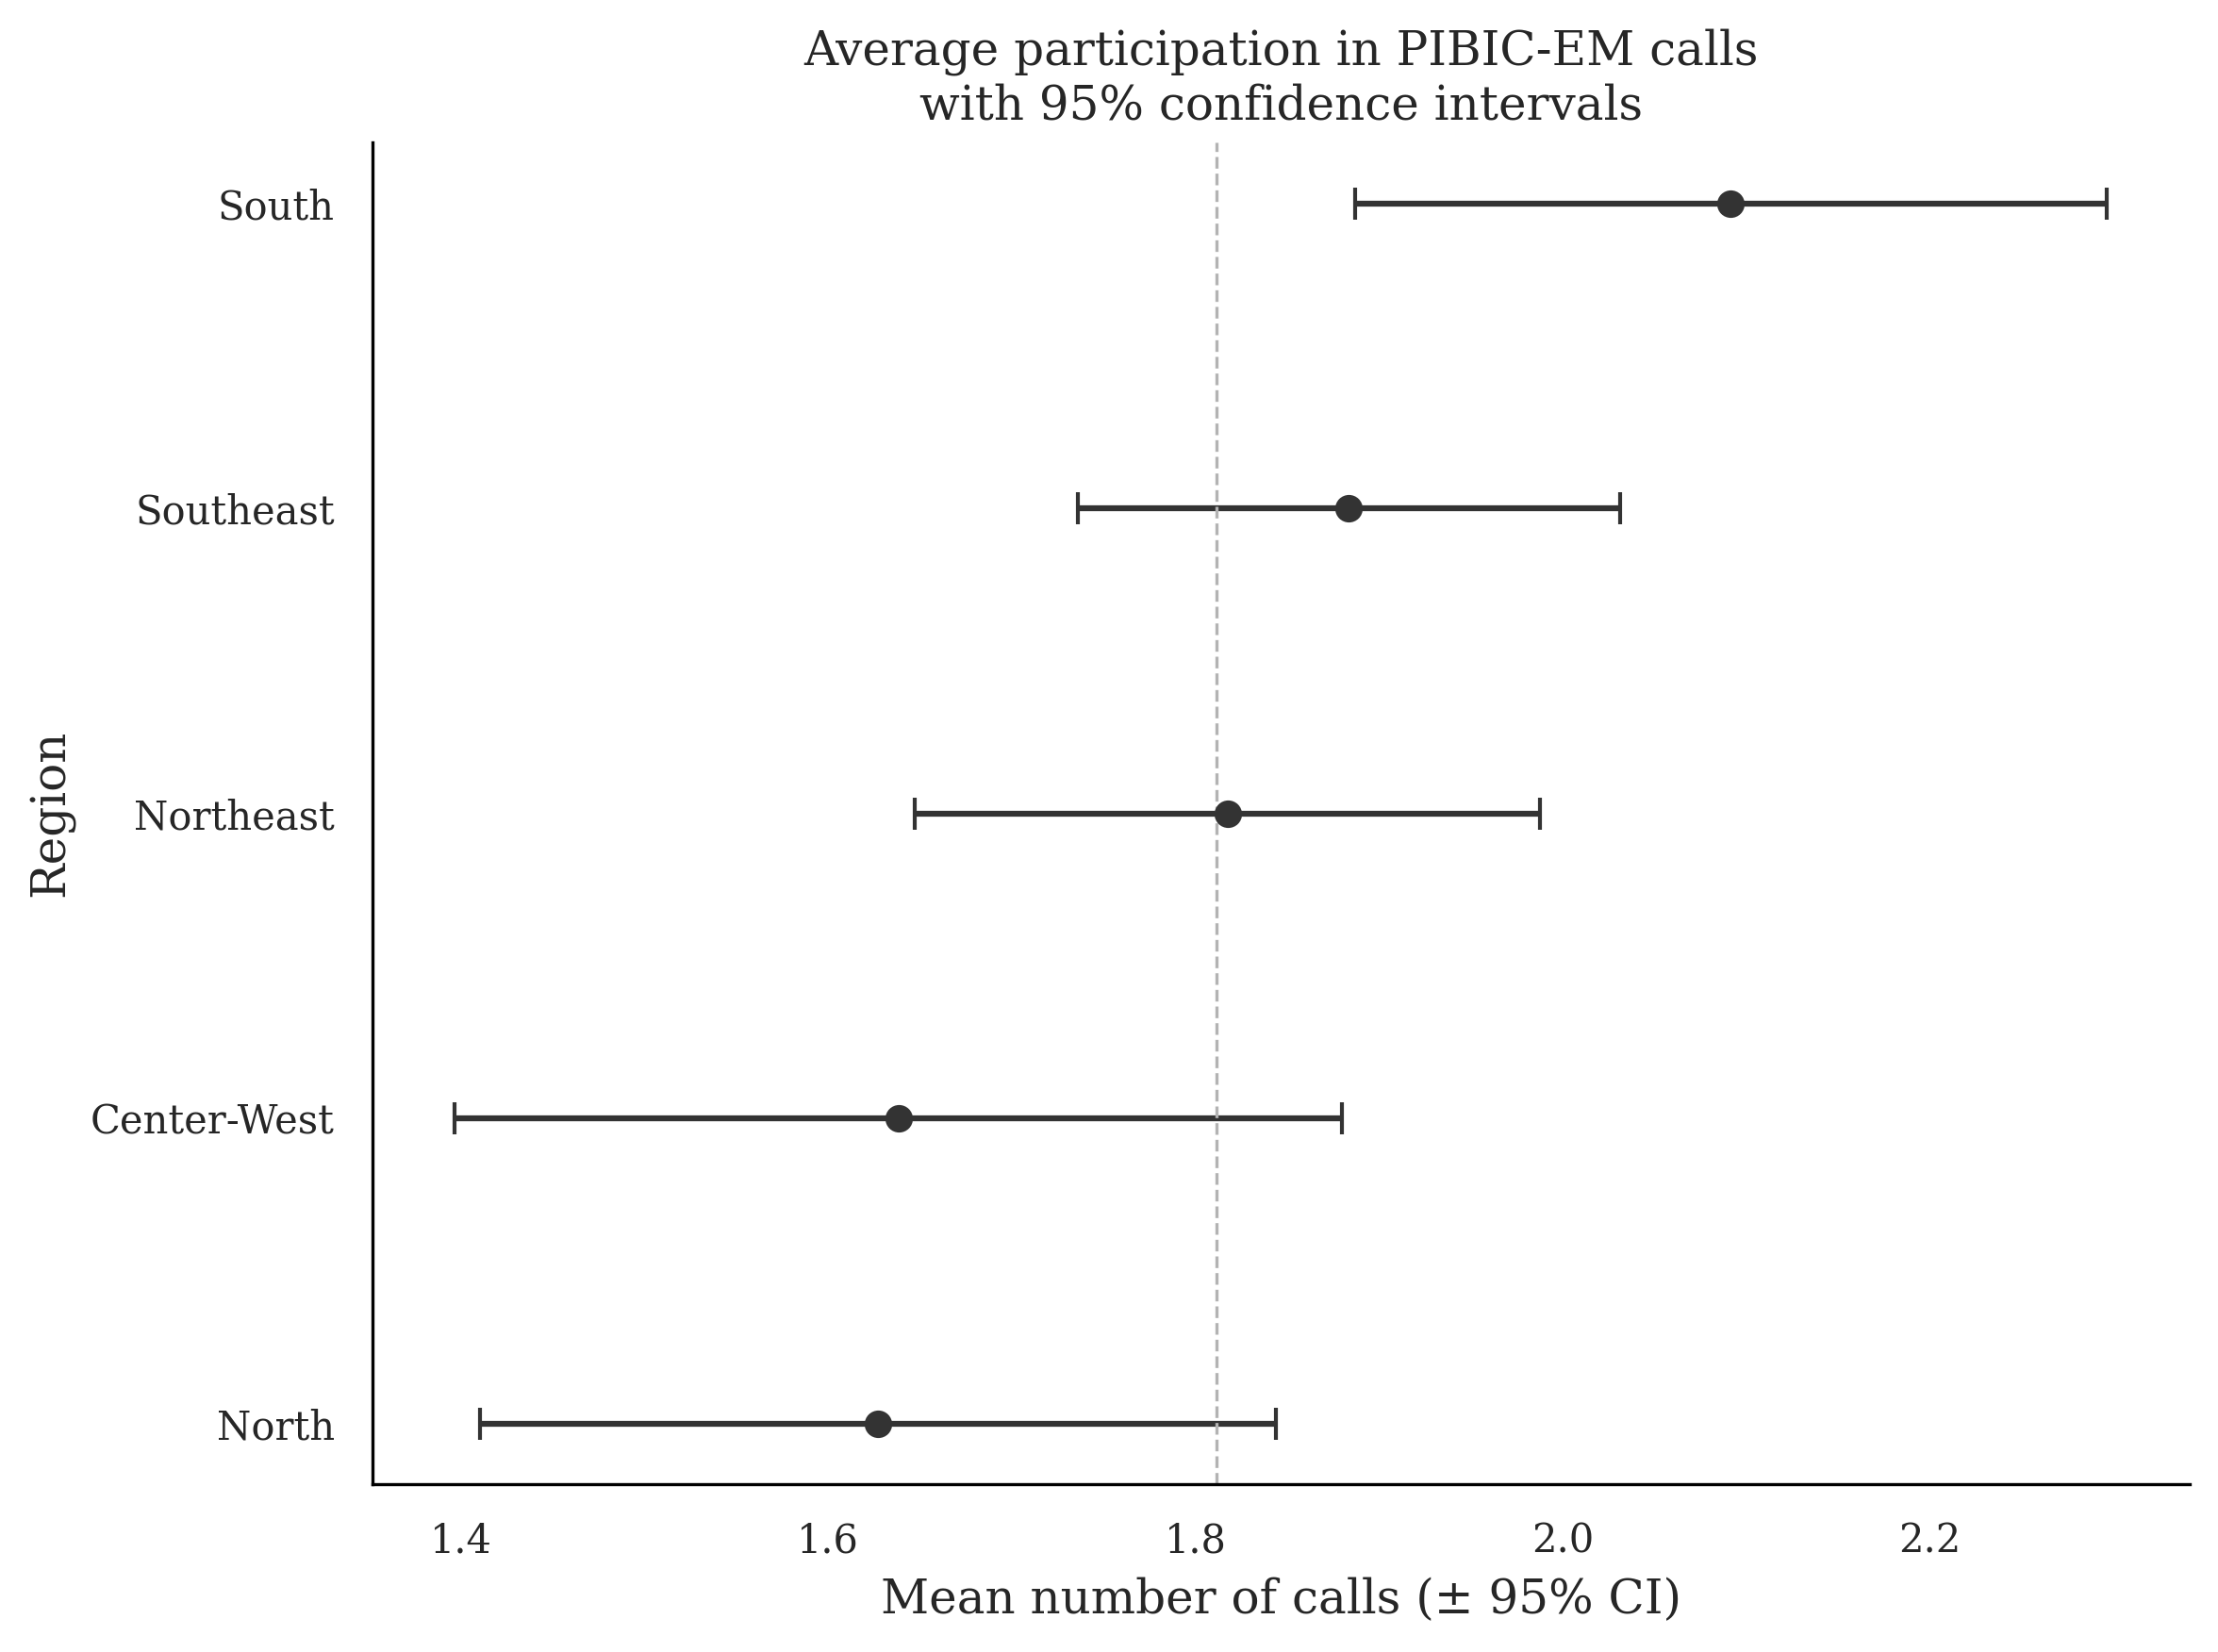

 -> fig_regioes_forest_EN_color.png


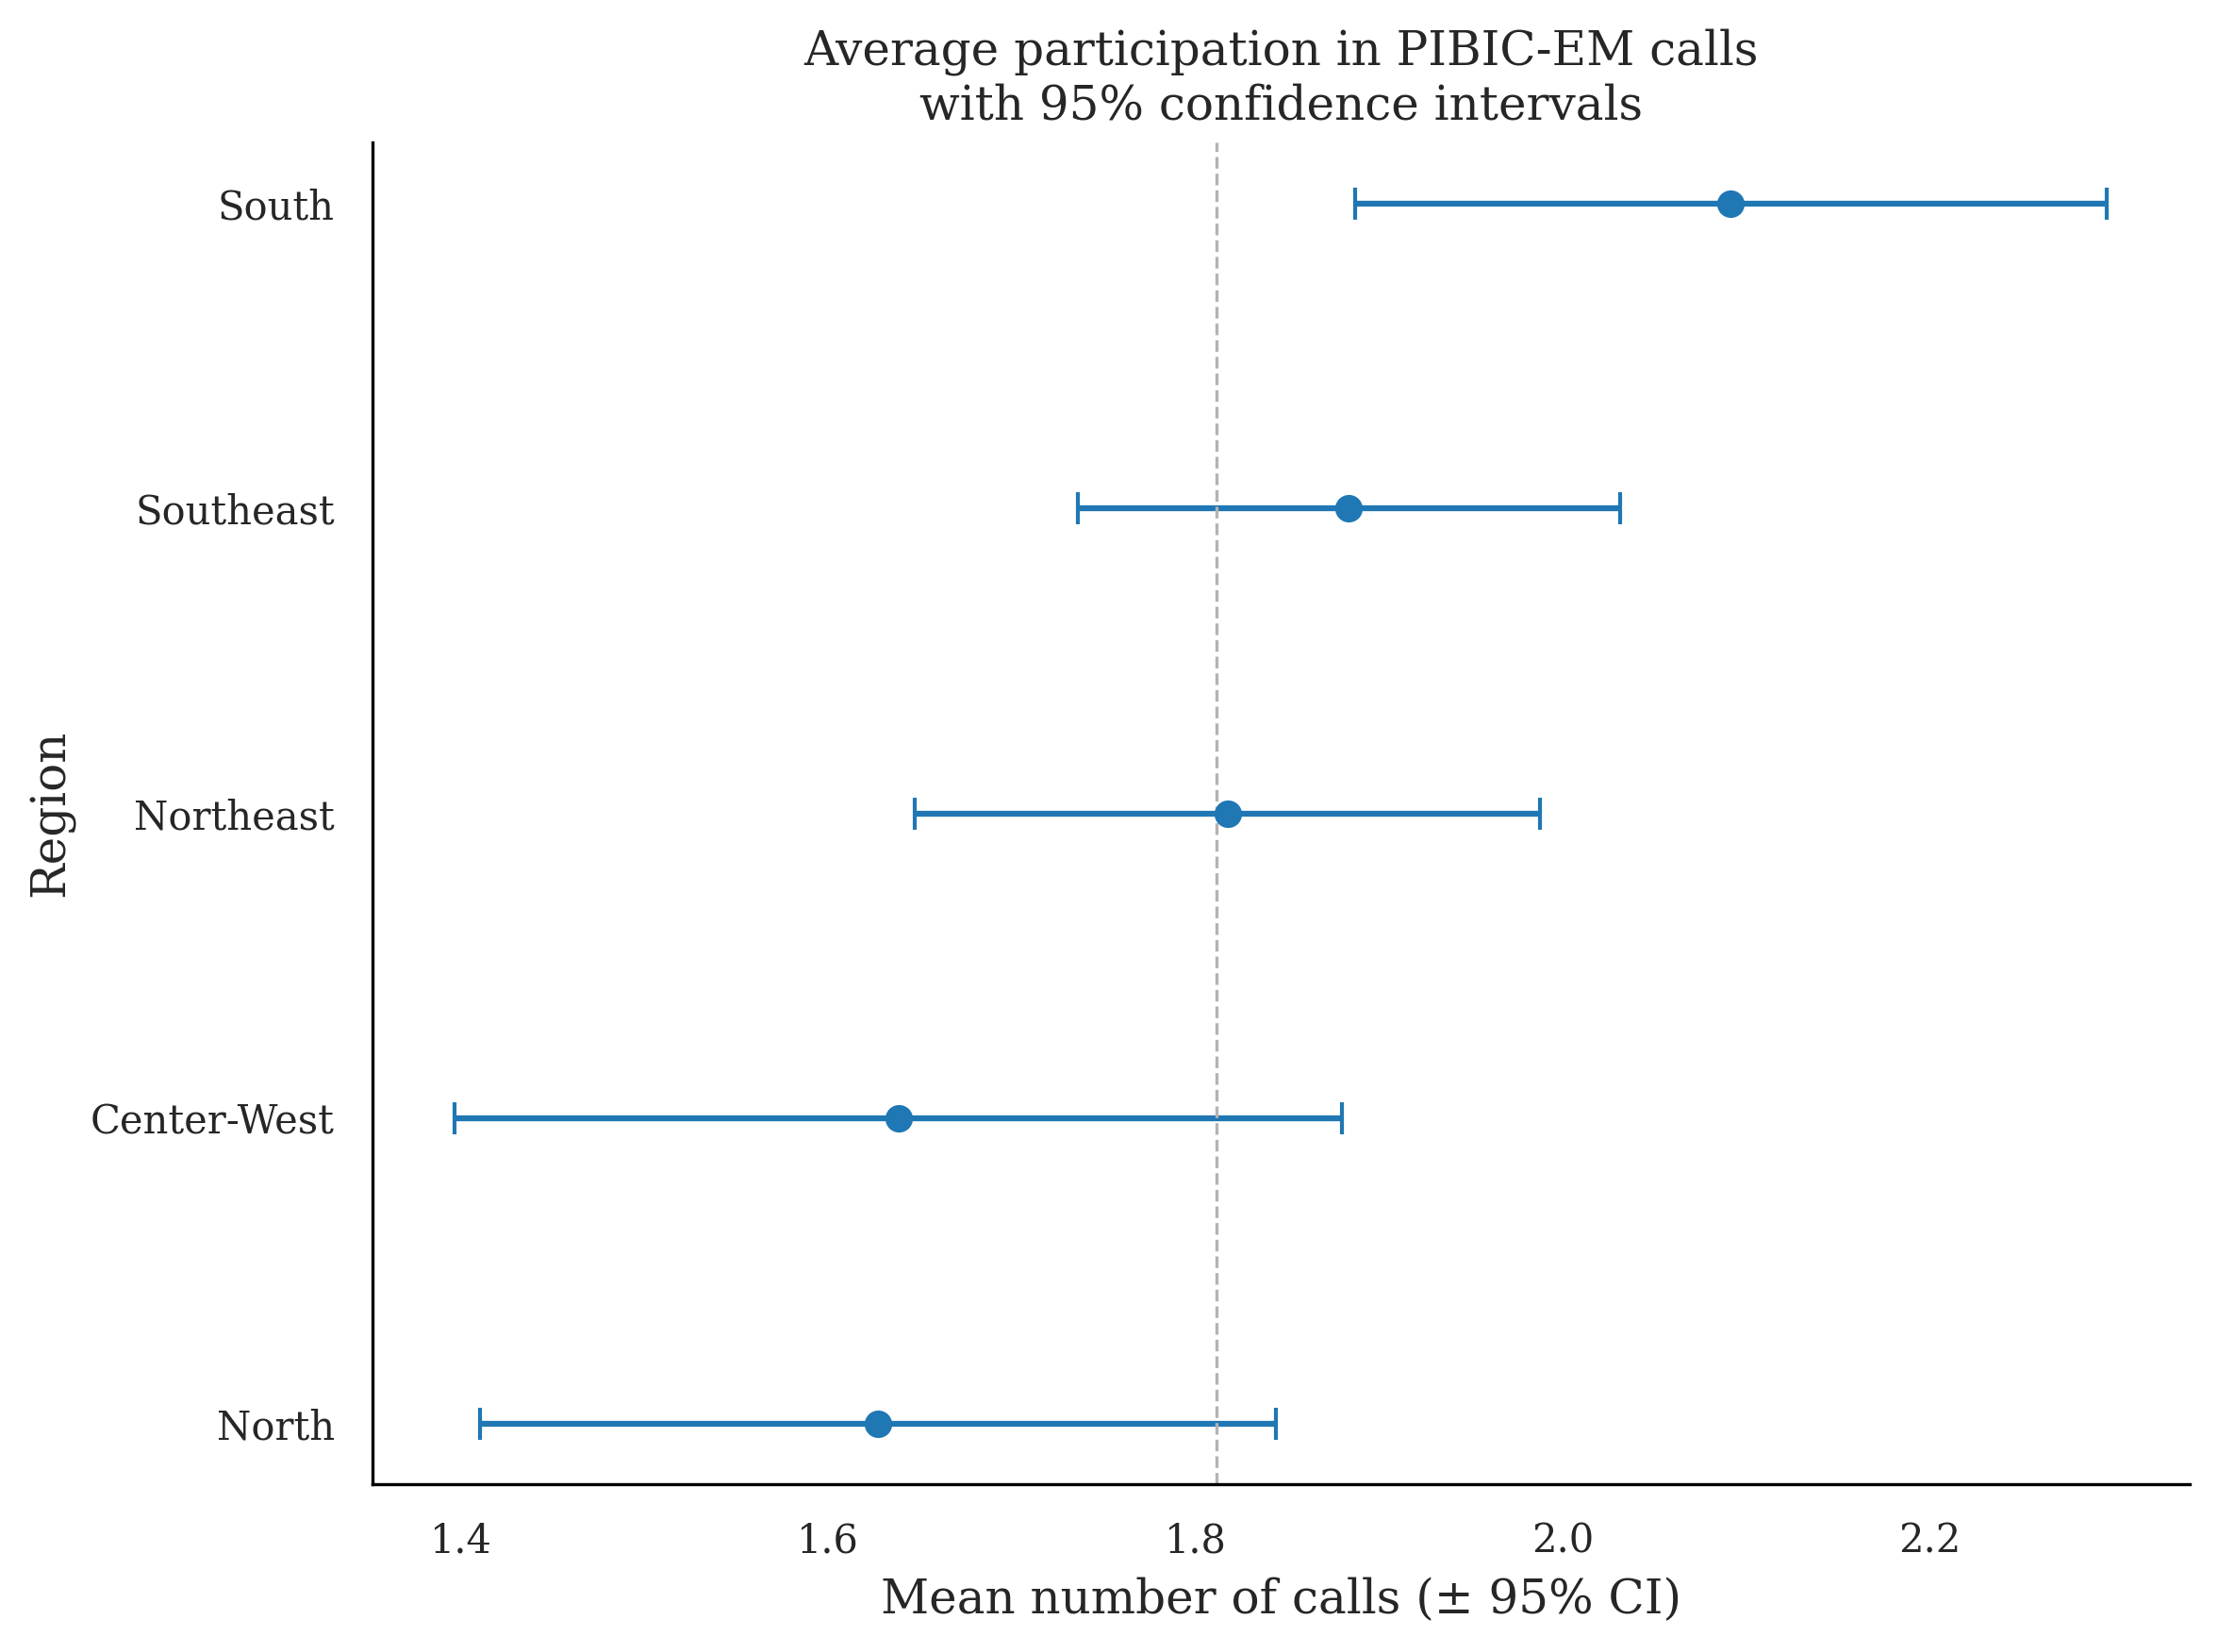


✔️ Todas as visualizações por região foram geradas e salvas na pasta atual.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from IPython.display import display

sns.set(style="whitegrid")

def estilo_apa():
    mpl.rcParams.update({
        "font.family": "DejaVu Serif",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 300,
    })

# 2. Montar Drive (apenas no Colab) e carregar base
# ------------------------------------------------------------
#try:
#    from google.colab import drive
#    drive.mount("/content/drive")
#    EM_COLAB = True
#except ImportError:
#    EM_COLAB = False
#    print("Não está no Colab – ajuste o caminho do arquivo manualmente.")

# Caminho do arquivo exportado do Jamovi
caminho_arquivo = "/content/2025_11_20_participacao_PIBIC-EM_regioes_v3.csv"

# Se o seu CSV usa ponto e vírgula como separador, troque a linha abaixo pela comentada
df = pd.read_csv(caminho_arquivo)
# df = pd.read_csv(caminho_arquivo, sep=";")

print("Dimensões da base:", df.shape)
df.head()

# 3. Configurar variáveis e rótulos PT/EN
# ------------------------------------------------------------
var_participacao = "num_chamadas_participou"
var_regiao       = "regiao_corrigida"

# Conferir valores únicos de região
print("\nRegiões na base:")
print(df[var_regiao].value_counts())

map_regiao_pt = {
    "Centro-Oeste": "Centro-Oeste",
    "Nordeste": "Nordeste",
    "Norte": "Norte",
    "Sudeste": "Sudeste",
    "Sul": "Sul",
}
map_regiao_en = {
    "Centro-Oeste": "Center-West",
    "Nordeste": "Northeast",
    "Norte": "North",
    "Sudeste": "Southeast",
    "Sul": "South",
}

df["regiao_pt"] = df[var_regiao].map(map_regiao_pt)
df["regiao_en"] = df[var_regiao].map(map_regiao_en)

# 4. Tabela-resumo descritiva por região
# ------------------------------------------------------------
resumo = (
    df
      .groupby(var_regiao)[var_participacao]
      .agg(
          N="count",
          media="mean",
          mediana="median",
          desvio_padrao="std",
          minimo="min",
          maximo="max",
      )
      .reset_index()
)

# Erro-padrão e IC95%
resumo["se"]   = resumo["desvio_padrao"] / np.sqrt(resumo["N"])
resumo["ic95"] = 1.96 * resumo["se"]

# Acrescentar rótulos PT/EN na tabela-resumo
resumo["regiao_pt"] = resumo[var_regiao].map(map_regiao_pt)
resumo["regiao_en"] = resumo[var_regiao].map(map_regiao_en)

# Ordenar pela média (do maior para o menor) – útil para os gráficos
resumo = resumo.sort_values("media", ascending=False).reset_index(drop=True)

print("\nResumo descritivo por região:")
display(resumo.round(2))

# 5. (Opcional) Recalcular o Kruskal–Wallis em Python só para conferência
# ------------------------------------------------------------
from scipy import stats

grupos = [g[var_participacao].values for _, g in df.groupby(var_regiao)]
kw_stat, kw_p = stats.kruskal(*grupos)
print(f"\nKruskal–Wallis (checagem em Python): H = {kw_stat:.2f}, p = {kw_p:.3f}")

# 6. Paletas de cor
# ------------------------------------------------------------
# Mesma ordem em todos os gráficos
ordem_regioes = resumo[var_regiao].tolist()

# Paleta colorida (uma cor por região)
paleta_color = sns.color_palette("colorblind", len(ordem_regioes))

# 7. Gráfico 1 – Barplot média + IC95% por região
#    (PT/EN × cinza/colorido)
# ------------------------------------------------------------
def grafico_bar_regiao(idioma="pt", palette="gray"):
    estilo_apa()
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    if idioma == "pt":
        label_col = "regiao_pt"
        xlabel   = "Região"
        ylabel   = "Média de chamadas que o pesquisador participou"
        titulo   = "Participação média em chamadas do PIBIC-EM por região"
    else:
        label_col = "regiao_en"
        xlabel   = "Region"
        ylabel   = "Mean number of calls per researcher"
        titulo   = "Average participation in PIBIC-EM calls by region"

    # Ordenar resumo pela média (já está ordenado desc)
    dados = resumo.copy()
    dados = dados.sort_values("media", ascending=False).reset_index(drop=True)

    # Barplot básico
    barra = sns.barplot(
        data=dados,
        x=label_col,
        y="media",
        ax=ax,
        edgecolor="black",
        linewidth=0.8
    )

    # Aplicar cores manualmente (evita FutureWarning do seaborn)
    if palette == "gray":
        cores = ["0.8"] * len(dados)
    else:
        cores = paleta_color

    for patch, cor in zip(ax.patches, cores):
        patch.set_facecolor(cor)

    # Barras de erro (IC95%)
    ax.errorbar(
        x=np.arange(len(dados)),
        y=dados["media"],
        yerr=dados["ic95"],
        fmt="none",
        ecolor="black",
        elinewidth=1,
        capsize=5,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    plt.xticks(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()
    return fig

arquivos_barra = {
    "PT_gray":  ("fig_regioes_bar_PT_cinza.png", "pt", "gray"),
    "PT_color": ("fig_regioes_bar_PT_color.png", "pt", "color"),
    "EN_gray":  ("fig_regioes_bar_EN_gray.png",  "en", "gray"),
    "EN_color": ("fig_regioes_bar_EN_color.png", "en", "color"),
}

print("\nGerando Gráfico 1 (barplots média + IC95%)...")
for _, (arquivo, idioma, paleta) in arquivos_barra.items():
    print(f" -> {arquivo}")
    fig = grafico_bar_regiao(idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

# 8. Gráfico 2 – Boxplot de participação por região
#    (PT/EN × cinza/colorido)
# ------------------------------------------------------------
def grafico_box_regiao(idioma="pt", palette="gray"):
    estilo_apa()
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    if idioma == "pt":
        label_col = "regiao_pt"
        xlabel   = "Região"
        ylabel   = "Número de chamadas que o pesquisador participou"
        titulo   = "Distribuição da participação em chamadas do PIBIC-EM por região"
    else:
        label_col = "regiao_en"
        xlabel   = "Region"
        ylabel   = "Number of calls per researcher"
        titulo   = "Distribution of participation in PIBIC-EM calls by region"

    ordem_labels = resumo.sort_values("media", ascending=False)[label_col].tolist()

    box = sns.boxplot(
        data=df,
        x=label_col,
        y=var_participacao,
        order=ordem_labels,
        width=0.6,
        ax=ax
    )

    # Recolorir boxes
    if palette == "gray":
        cores = ["0.8"] * len(ordem_labels)
    else:
        cores = paleta_color

    for patch, cor in zip(ax.artists, cores):
        patch.set_facecolor(cor)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    plt.xticks(rotation=45, ha="center")
    plt.tight_layout()
    plt.show()
    return fig

arquivos_box = {
    "PT_gray":  ("fig_regioes_box_PT_cinza.png", "pt", "gray"),
    "PT_color": ("fig_regioes_box_PT_color.png", "pt", "color"),
    "EN_gray":  ("fig_regioes_box_EN_gray.png",  "en", "gray"),
    "EN_color": ("fig_regioes_box_EN_color.png", "en", "color"),
}

print("\nGerando Gráfico 2 (boxplots por região)...")
for _, (arquivo, idioma, paleta) in arquivos_box.items():
    print(f" -> {arquivo}")
    fig = grafico_box_regiao(idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

# 9. Gráfico 3 – Forest plot (pontos com IC95%) por região
#    (PT/EN × cinza/colorido – cores afetam apenas os pontos)
# ------------------------------------------------------------
def grafico_forest_regiao(idioma="pt", palette="gray"):
    estilo_apa()
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # ordenar da menor para a maior média
    dados = resumo.sort_values("media", ascending=True).reset_index(drop=True)

    if idioma == "pt":
        label_col = "regiao_pt"
        xlabel    = "Média de chamadas (± IC 95%)"
        ylabel    = "Região"
        titulo    = "Participação média em chamadas do PIBIC-EM\ncom intervalos de confiança (95%)"
    else:
        label_col = "regiao_en"
        xlabel    = "Mean number of calls (± 95% CI)"
        ylabel    = "Region"
        titulo    = "Average participation in PIBIC-EM calls\nwith 95% confidence intervals"

    y_pos = np.arange(len(dados))

    if palette == "gray":
        cor_ponto = "0.2"
    else:
        cor_ponto = "#1f77b4"  # azul padrão

    ax.errorbar(
        x=dados["media"],
        y=y_pos,
        xerr=dados["ic95"],
        fmt="o",
        color=cor_ponto,
        ecolor=cor_ponto,
        capsize=4
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(dados[label_col])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axvline(x=dados["media"].mean(), color="0.7", linestyle="--", linewidth=0.8)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()
    return fig

arquivos_forest = {
    "PT_gray":  ("fig_regioes_forest_PT_cinza.png", "pt", "gray"),
    "PT_color": ("fig_regioes_forest_PT_color.png", "pt", "color"),
    "EN_gray":  ("fig_regioes_forest_EN_gray.png",  "en", "gray"),
    "EN_color": ("fig_regioes_forest_EN_color.png", "en", "color"),
}

print("\nGerando Gráfico 3 (forest plots)...")
for _, (arquivo, idioma, paleta) in arquivos_forest.items():
    print(f" -> {arquivo}")
    fig = grafico_forest_regiao(idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

print("\n✔️ Todas as visualizações por região foram geradas e salvas na pasta atual.")